# 📊 SHAP Interpretation Report: LSTM
This notebook provides a post-hoc explanation of the model's predictions using **gradient** SHAP.

---

### 🔍 What are SHAP Values?
**SHAP (SHapley Additive exPlanations)** decomposes a model's prediction into the contribution of each individual feature. 
* **Magnitude:** A larger absolute SHAP value means the feature had a bigger impact on the output.
* **Direction:** A positive SHAP value means the feature pushed the prediction *higher*, while a negative value pushed it *lower*.
* **Interpretation:** For any given sample, the sum of SHAP values plus the base value (average model output) equals the actual model prediction.

### 🧪 Methodology
**Gradient SHAP** is designed for deep learning models. It explains predictions by computing the gradients of the output with respect to the inputs, integrated over various reference points (baselines). It is highly efficient for neural networks.

---

### 📋 Metadata
**Model Architecture:** LSTM  
**Analysis Context:** timeseries  
**Dataset Scope:** whole

---


In [1]:
import shap
import numpy as np
import matplotlib.pyplot as plt

# Data provided by the explainer
all_shap_dict = {0: [[[[9.354227208072815e-05], [0.00019217174558348526], [-5.301499859472873e-06], [0.00021631023942701177], [2.1513567734113948e-05], [2.759854076673174e-05], [0.004994622969364159], [0.0003093654949650457], [-9.988598217798428e-05], [-0.00014008614031856754], [-0.001137548713901455], [0.007045836631149687]], [[-0.000867466773095871], [-0.0016503558729926851], [0.00011021201845054779], [0.0008879927141264487], [7.414134378506687e-05], [-0.0005822182108099459], [0.008426316594763016], [0.0014533896984566324], [0.001209216138044475], [-0.000468671323645437], [-0.0013142275047417517], [0.0130355242928194]], [[0.0007760890997681472], [-0.0021049497779975085], [-0.0011155265446819891], [-0.0010050620877620523], [-0.00024900637153042044], [-0.00032722107187998324], [0.02411818927301577], [0.0010741890493554224], [-0.0023621093851810965], [0.0004189488306405778], [0.006091094477613312], [0.0065848084197639555]], [[0.014543948025952918], [0.04995239816848848], [0.015167988329265431], [-0.012298502822625894], [-0.0008599073952604414], [0.005009350201019933], [0.020743847705961747], [-0.00043078949172725765], [0.00030636097093076904], [-0.001167577292252663], [-0.018467359739173198], [0.027506282069713266]], [[-0.003545537952879043], [-0.09871679080354355], [-0.011129183557380865], [0.00030069055964059504], [0.0016384121999475497], [0.03916827796394638], [0.03345784339133938], [-0.004252855290945375], [-0.0021021341874869672], [-0.012000820912601108], [0.010722702947408326], [0.017366579602526692]], [[0.16734850536687962], [0.2137596164930292], [0.012394638159060826], [-0.01813925873685746], [-0.026161540281483986], [0.030211918708146657], [0.07959966076149506], [0.035284081343258625], [-0.02414554799760352], [0.011218200598676], [0.01965402246490537], [0.028541532559504253]]], [[[0.0006069971200896952], [0.0018728992597820105], [0.00025740544225861855], [0.0012692657964319656], [9.826496684222471e-05], [0.00041012507642528495], [0.0020254415666033543], [7.33341632408243e-05], [-0.00012400032226075015], [-0.00024151182884374329], [-0.004168984209575651], [0.01117334055094955]], [[-0.008956911353622843], [-0.010781199001790531], [0.0023059197301615996], [0.0037839537467223884], [0.0009278172120039937], [-0.003102753831039816], [-0.012134874534932817], [0.0016952418077101719], [0.006346816201716292], [-0.002170119887942334], [-0.0068074808136441125], [0.028222634265859504]], [[0.022064232923240463], [-0.004856567392568596], [-0.009878567023291622], [0.006678558015791248], [-0.0029583647391399526], [0.018334889259500737], [0.035917218087904434], [0.002037133919655088], [-0.0013408975350912358], [-0.0033855414067599167], [-0.005957944161533504], [-0.03421954440615231]], [[0.07095207386827117], [0.1928015342602459], [0.034727829401378536], [-0.037319044148917284], [-0.012506444925622775], [0.002476754331778697], [0.03153819215425415], [0.009278650813140308], [-0.004401665684008778], [0.012059992674990501], [-0.024027133418494367], [0.04744534095977893]], [[-0.12202206194578638], [-0.2850149758491067], [-0.005092233266439266], [0.03211354971410754], [0.025238198807121397], [0.0005481514267128443], [0.00010326384079568499], [-0.02129164787595612], [0.03110161252491372], [-0.02234715115643924], [-0.0003646970232632166], [0.07646654007981833]], [[0.41326436364653574], [0.397785559230673], [0.03879154231398954], [-0.07186768905990468], [-0.05141125111131957], [0.027205634123152543], [0.06491268407924958], [0.03985152055189017], [-0.04679833373813851], [0.009856637643321118], [0.009962206644300644], [-0.07347617929141871]]], [[[0.002505616802776578], [0.005335740429826719], [0.0027330887457377414], [0.006197803440903399], [-0.0004873345442555846], [0.0013987425219675106], [0.006306324373811022], [-0.002148038675081406], [0.0012103744685740758], [-0.0030003300690604313], [-0.014505943393233467], [0.013964162610902268]], [[-0.03261953348943123], [-0.07602539134737427], [-0.002958356832563535], [0.0011113175607579619], [0.0024291398596453634], [-0.015145535701619552], [-0.01064712902854877], [-0.004168576319525412], [0.006194368052006082], [-0.0016326590164504478], [0.0004883895330918692], [0.01948310427584863]], [[0.09698937801898853], [0.1066215653389068], [-0.0010375866202271596], [-0.012790368840722821], [-0.017143023693083532], [0.05752106151981014], [0.06095826092521525], [0.012035918910331865], [-0.014394818298248815], [0.0003265351652490011], [0.0008315421074880215], [-0.004705465492475561]], [[-0.013876892035619749], [0.05234574218084966], [0.050617243687422014], [-0.008027143527639221], [-0.011056557444979702], [0.0018065213914491849], [0.0074255057162581585], [0.012888067640152904], [0.009061446526032609], [-0.0009511578303287294], [-0.02318868670070823], [0.11209586779424548]], [[-0.12251778880079424], [-0.25697795417915525], [-0.014774241009871281], [0.003715816833244954], [0.013980981418980498], [0.0013498595375829763], [0.03490522911777407], [-0.05726329243796165], [0.030517908857883816], [-0.025616375223269622], [-0.032401979528137684], [0.06948509375715176]], [[0.5454968489307086], [0.7568095641813655], [0.08848577941829841], [-0.07949446750114894], [-0.07028800476953165], [0.06606149647308357], [-0.0048330599435426605], [0.08121472701959402], [-0.05103253630510679], [0.010692536072314568], [-0.002499959211660434], [-0.09067832056095489]]], [[[-0.004498653823083448], [-0.0009130353763994359], [0.003832477207969851], [0.003367608507507039], [0.0005293634233322498], [-0.004112413487703272], [-0.0006393126320728479], [6.703531698195593e-05], [0.002433947891184154], [-0.0006532718559622167], [-0.00646930731582954], [0.010198442773194006]], [[-0.0074451219081327095], [-0.04370764551355241], [-0.004632689755314526], [0.007799494881380296], [0.002077316528024061], [0.0021298948654842388], [0.01204645943373643], [-0.002081238945009573], [0.002503773166571247], [-0.0024514180098177264], [-0.0016097361527865105], [-0.005086939409660086]], [[0.05402913360215736], [0.08883903494335069], [0.012398068784511329], [-0.013310494817864688], [-0.012232352558054627], [0.008230519037723816], [0.017426981072364775], [0.01035861609680248], [-0.016906492142363984], [0.0047923297744934005], [0.00739093619229023], [0.008857393751600271]], [[-0.07762587106425198], [-0.09146807148679531], [0.016157004968598503], [0.014872089254844118], [0.009863841252730918], [-0.0009446142829871984], [0.0013422043099607045], [0.006406520437607794], [0.018709356908397326], [-0.004547687297005843], [-0.006831999703125025], [0.08659496272061401]], [[0.0827722733182772], [0.04985653014795119], [0.017592065329460588], [-0.0416613533301601], [-0.021607797240768292], [0.015686976273208836], [0.009607253924762225], [-0.03471411536187346], [0.0013255450669652643], [-0.00984870888460133], [-0.02978121712354511], [-0.03410183796057697]], [[0.27061729666845336], [0.3483471961639434], [0.030214612921182046], [-0.011920545191089862], [-0.034116957467540295], [0.009302999397762217], [-0.05019552564612212], [0.05345568108405919], [-0.03381059352939147], [0.01074604596374456], [0.020771220387980946], [0.038162586030049635]]], [[[0.023103678309670517], [0.040704953504427765], [0.0047047299791986375], [-0.002999880874797052], [-0.003651877573648951], [0.006484478646023791], [0.012353849430330776], [0.0036164166330590686], [-0.004095722065526484], [0.0018484862948565139], [-0.0017259350220486286], [0.0038432457399431253]], [[-0.03176731107109123], [-0.042367553559523916], [0.007568112028684428], [0.0055963822405349604], [0.003377584561838502], [-0.0033275394108838274], [0.004019805028145009], [0.00029033443358561896], [0.00806062862988989], [-0.0027428101401056593], [-0.002129723251099944], [0.029602952297603426]], [[0.045049501441852054], [0.023488348790801417], [0.008201030916732896], [9.154442985223932e-05], [-0.008501785928184702], [0.005055653209854099], [0.009639400070880372], [-0.004390490554955689], [-0.003020433400344241], [-0.0040071416916553785], [-0.00858154480692067], [-0.006144769497459577]], [[0.040909745307429864], [0.07219878168502813], [0.029538809389481585], [-0.015018684049922069], [-0.0037848174696261073], [0.009582538298265582], [0.00985095206137442], [0.015738773231074362], [-0.00995534153227103], [0.0021161340688149836], [0.006231245932445819], [0.04557998824318962]], [[-0.0795635150497071], [-0.2557433980253515], [-0.029159733372306228], [0.016094625357899336], [0.012160872806118581], [-0.0007166956449011614], [-0.008257850512060185], [-0.007748149677767196], [0.01110769099663319], [-0.01080355820751425], [0.0074961369063496295], [0.09313120906670179]], [[0.36881844294688576], [0.3375737445362434], [0.05869368103443708], [0.0035243891489483074], [-0.045276057955154034], [0.007193029920676383], [-0.1245902351198574], [0.05540018320489144], [-0.030498282404594887], [0.006200402392070171], [0.010649604089369859], [0.01797002804977899]]], [[[-0.0038110410544918583], [-0.0017171502980718417], [0.005529499324590406], [0.003827351943249878], [0.00016066294152745434], [-0.0004264019193560882], [0.0012847024897944647], [0.0006458733246930892], [0.0012961589387296888], [-0.0005364742938117974], [-0.0017321312993014428], [0.009258725269260946]], [[-0.006185015547812192], [-0.018229462577536777], [0.0010431933594854859], [0.0020267075285995526], [-7.044453088651103e-06], [0.00010193742904011844], [0.0053725619941501065], [-0.0027742242381280898], [0.0015342310257364941], [-0.0016969301417854737], [-0.0021382439110268717], [0.007605168531026204]], [[0.04656763508203143], [0.06108128505375032], [0.012165730297592275], [-0.0023096998407953657], [-0.005683102262667724], [0.007839348189993559], [-0.0024302233795472747], [0.010972147977965202], [-0.00936448351879965], [0.0017551292799579425], [0.005438796283028258], [0.007331236273727842]], [[-0.03223330712192053], [-0.08506272031948846], [0.008646787186952094], [0.025252218239265125], [0.0077933157891797175], [0.0006029026309167001], [0.003461798715202964], [0.0026788090516198728], [0.005815489205842792], [-0.0037200746728837837], [-0.0017593757305361282], [0.061932437519048235]], [[0.042920278691780424], [-0.009298103092283733], [-0.011708463400079307], [-0.00327713216543849], [-0.014125768985179876], [-0.0007225952752501152], [-0.05791290011377403], [0.01852091733652087], [-0.0070002822663018695], [0.0016767162436183989], [0.007442473792129414], [0.0695967295069547]], [[0.08621443909471807], [0.16608124152777148], [0.06596983292380665], [0.029699870047262183], [-0.0236141546101318], [0.024339877016932708], [-0.1310141543080531], [0.031114436446118256], [-0.013880229853909177], [0.006172451433812865], [0.012741677133681848], [0.038247161040891146]]], [[[-0.004241832259101941], [-0.006322910368432572], [0.00030331183428274256], [0.004043095863858326], [0.0003397639259863629], [3.9982002440889394e-05], [0.0013605897836024134], [0.0010167874096835394], [0.0014309841201262802], [-0.0007277119952831077], [-0.0006390625127809337], [0.008111310641895483]], [[0.0016829388119387215], [-0.001019728622137729], [0.0010377753589565152], [-0.0018216106848514568], [-0.002864129765859492], [0.0013156143143965779], [0.001534953467364173], [0.0010880000749379209], [-0.0002814106662510165], [-0.0006096092998186903], [-0.00029859328395097763], [0.012173738634853569]], [[0.00917884459414149], [-0.006000399966350861], [0.0003429446990168591], [0.004554491251162239], [-0.0012852779231681028], [0.0017008416735021614], [-0.006051547576357691], [0.006706300811291252], [-0.0019997812228907466], [-8.565625608196701e-05], [0.0030901912249544955], [0.02674173425546917]], [[0.007310292661044244], [-0.007529328254039157], [0.010596972625467186], [0.008489162008564484], [-0.004601455375222323], [0.001624983839643652], [-0.02200133804999839], [0.009116211111018046], [-0.0003526388659391453], [-0.0011277541357045096], [-0.0006803683403713154], [0.056892455631565426]], [[-0.0035400998132761818], [-0.03342401755854046], [-0.010539487412735643], [0.005261887423785127], [-0.00684823142114263], [-0.008418839362586906], [-0.08735830827723291], [0.023261711121314296], [-0.001570518104307461], [0.0021589749097400803], [0.009428611954273169], [0.08325569617820211]], [[0.08929575898003592], [0.12664872544192318], [0.030961958969509817], [0.011160326917745472], [-0.021863774995427396], [0.02354535977281739], [-0.15874965626497098], [0.022980390922723935], [-0.005551179949013885], [0.002714256219775863], [0.0016162362609244184], [0.0291740661201211]]], [[[0.000859848664907945], [-9.230820748542638e-05], [0.0012185690883353478], [0.001301606096164555], [-0.0004167948304813492], [0.0007051616386075888], [0.0005468993452822707], [0.001796434592412114], [-0.0003744880888448724], [-0.00011173912624442183], [0.0004497654166889431], [0.006822901351676862]], [[-0.003835758922325966], [-0.014428645558276321], [2.8189788791941792e-05], [0.005016537278811755], [5.85705413371986e-05], [0.00023117624734811937], [-0.0036026254714833146], [0.0033964458113912442], [3.811000420491045e-05], [-0.0002792597024756438], [0.0013046756824161793], [0.014225829544223714]], [[0.012502924895954518], [0.004258389988457398], [0.006344172270195169], [0.002850689560163062], [-0.0029988881128510665], [0.0011406116152187069], [-0.01601276112935136], [0.004090956151941089], [-0.0016086545226993176], [-0.0001566421120831992], [-0.0002280511021267127], [0.02391497995076411]], [[0.0004786036485236956], [-0.010857749546862907], [0.003327184325878943], [0.006498568589278434], [-0.002456424718322439], [-0.00023450007142538333], [-0.04118005382273941], [0.008132938774083323], [0.000588526558643047], [-0.0006526692078608419], [0.00021732619714158298], [0.04385278914938592]], [[0.011450930223998736], [0.00728907681694698], [-3.505691775619347e-05], [0.00293645495536617], [-0.005937717823394326], [0.0004113804545799785], [-0.08451546359849135], [0.013048402259646773], [-0.0017420418158774354], [0.0021664601675395415], [0.0037305064446720355], [0.039855906246935406]], [[0.037041102002118916], [0.03919221952515852], [0.013975841867005925], [0.004094956414360357], [-0.005804473493043617], [-0.0005523380645731678], [-0.09150933654795856], [0.0015080176827685127], [-0.002406114444888407], [0.0008706681105616843], [0.00216415784532893], [0.018464039991054643]]], [[[-0.0004910686906492428], [-0.0038697969896931985], [0.000474854284324885], [0.0032359844685424326], [0.00013545248966977412], [9.816408420948199e-05], [-0.0007451118631944542], [0.0015106308935394646], [-0.00014025475078274874], [-0.00010511101940343797], [0.0004593382115683347], [0.006249754852015574]], [[-0.0013221824735132784], [-0.004591734614357218], [0.0014725521997183775], [0.002928285066728069], [-0.0004236832224570979], [-5.127088529828643e-05], [-0.006917776197741237], [0.0032762095981815624], [-8.875734305726989e-05], [6.025029946666033e-05], [0.000621557846114262], [0.012111604713002462]], [[0.0021332912220213764], [-0.00020124934576370122], [0.0022416581637014097], [0.0025569334576102023], [-0.0019961444099693745], [0.0005967689602635648], [-0.02207131104504969], [0.004739131513770824], [-0.00029357710031786187], [0.00015196463210957], [0.0005160123475201088], [0.017319449839752015]], [[0.006808545974687612], [0.007539808253464904], [0.003648776778953581], [0.002120303659024497], [-0.002603775169998933], [0.001839207674981963], [-0.033214311708576735], [0.004440209270824724], [-4.157121074956525e-05], [-0.0002872494943700613], [-0.0013420545057962253], [0.019487438285980443]], [[-0.0006742065735906189], [-0.004411428876556915], [-0.0015099838586928923], [0.0012377200038420466], [-0.0008124728975493307], [-0.0003442127985035388], [-0.038472558413653574], [0.0016919881203704059], [4.9534130674196274e-05], [0.0015709162235400644], [0.003500876844462105], [0.021864893114677663]], [[0.0023882970895329823], [-0.0019108127205859457], [0.0008796229831183062], [0.0009688569953445059], [-0.0023333047780419395], [0.0018226879667898083], [-0.06786550358900238], [-0.0054677277031955586], [-0.0006678084639527015], [0.00048164860835647164], [0.00027112553530660996], [0.005808424826708951]]], [[[-0.0002508628580471787], [-0.0018730375487443723], [0.0003318959010739391], [0.002273105718411282], [-0.00015425332257121993], [-0.00011310708291319775], [-0.0029374914072487967], [0.001690591174156853], [-0.0001264736904900988], [-6.451137275841645e-05], [0.00020063387020734623], [0.0060089626729027245]], [[-0.00023607360891095733], [-0.002038001004156714], [0.0011896004700579469], [0.0020067390992860325], [-0.0005754747688456751], [-0.0011283554233227251], [-0.011579129655261007], [0.0036976540203495735], [-1.6544737296002862e-05], [0.00011502789489886564], [0.0006019837558747359], [0.00992250915895183]], [[0.0034829095218000573], [0.003400754128599851], [0.0016283412371332665], [0.0011711364631694816], [-0.0014326448946342715], [0.0006874816952712956], [-0.02217667437823583], [0.0038681547188653366], [-0.00016558659239142146], [0.00014938183829191245], [-0.0001302365306261265], [0.011414509033281745]], [[0.0027077287575687286], [0.0019925328260000114], [0.0017334429375622817], [0.000961018326539927], [-0.0010016290100459727], [6.286157385888904e-05], [-0.02496029074978265], [0.0019051420132179422], [1.3266639309770277e-05], [-0.00016068359884659518], [-0.0004862251387537118], [0.014028705964413713]], [[-0.0015764986616525368], [-0.0020271687870591047], [-0.00016806383502917155], [0.00048821875920773195], [-0.00010029722644997266], [-0.002398870292936673], [-0.03512707337432469], [-0.0008698380956236367], [0.00019778519559123943], [0.0010716641274566537], [0.002731247749488995], [0.016789970892707836]], [[-0.007939809398196981], [-0.007160393415968507], [-0.0007020027479177268], [-0.00011811892291339856], [-0.0006442335353016932], [0.006444240903343282], [-0.05603123038096904], [-0.006088860362818036], [-0.0008972060976821411], [0.00020331948723447172], [-0.0005985662768758624], [0.003634171638931802]]], [[[1.0015001336418111e-05], [-0.0007276210885638014], [0.0003286162660408648], [0.00126249597046809], [-0.00024680962813698607], [-0.0005992608539167318], [-0.0037261441541253763], [0.0011017325851241499], [-1.4764283434706996e-05], [-5.4958118433865496e-05], [-3.2927413165483554e-05], [0.004283639369180775]], [[0.00017978639546087214], [-0.00043428662744571814], [0.0007430528082067655], [0.000730799875868146], [-0.0003376028937882052], [-0.0007072466444723386], [-0.009669901089274348], [0.002074154037793702], [8.526292189155344e-05], [9.221246916537675e-05], [0.00024856065242682463], [0.006417320808429424]], [[0.0012798805393147406], [0.000792430060514889], [0.000600362828740795], [0.0004842797293541451], [-0.0005861541707440451], [-5.759812328203055e-05], [-0.015150983556656847], [0.0015099975122146241], [7.305694500901535e-06], [0.000130927177563208], [6.994778273725676e-05], [0.007199267324380341]], [[0.0006794376447467871], [-1.2502984175156739e-05], [0.0002539147784844411], [0.00039350623914974093], [-0.0006660778655823671], [0.00015016504277749534], [-0.018922433277738633], [0.00010232323147524173], [2.123504468200809e-05], [-1.0171083369806333e-05], [-0.0008033421015468557], [0.009459151054189345]], [[-5.2923264293489086e-05], [0.0008498152217693493], [8.768515810227705e-05], [1.6426881308323213e-05], [0.00017009088398387234], [-0.002821350834637672], [-0.024817084761538325], [-0.0035909558556446656], [0.000334984116231977], [0.0005555193860704233], [0.002340666618494984], [0.012789785754020826]], [[-0.01123501456031579], [-0.013569224906081217], [-0.0005687261189617854], [-0.00022519876456919167], [0.0007624733227290833], [0.0017620576990357811], [-0.04352803031913227], [-0.008359768298769575], [-0.0011973934644113817], [-3.3029842264795377e-06], [-0.0014343934060428156], [-7.536465354180332e-05]]], [[[0.00015398821925201493], [-0.00010877694096471876], [0.00020029599445121], [0.0004321235620211229], [-0.00019533822387590456], [-0.000446284007436887], [-0.0032116468871187954], [0.0005361463909910998], [6.024680514684167e-06], [-2.253558825343894e-05], [-7.480606814878267e-05], [0.0028124860901745058]], [[-1.635711473150078e-06], [-0.0002499511141249133], [0.0003640060283199808], [0.0002989322483867231], [-0.00016230832597033667], [-0.0001454796026231687], [-0.0071579924580191835], [0.000819441414219746], [0.00011692599870554977], [0.00010511752861693513], [0.00016298438627620205], [0.0041711544464036795]], [[0.00040327806306431166], [0.00017009214910125185], [5.7530594021990444e-05], [0.00018975900396062923], [-0.00038054336838641475], [-0.00011664426289976685], [-0.010891922850908448], [8.484817912717178e-05], [3.902256476413458e-05], [0.00012226817595698054], [9.852370895621046e-06], [0.004701981654295009]], [[-0.0005145067732355425], [-0.0004939553259267832], [-3.463576473190251e-05], [7.252789007309613e-07], [-0.0002454528963563132], [0.0007302132824720268], [-0.011650715831106192], [-0.001058969735801211], [2.8608459615997816e-05], [-0.0001578862846870861], [-0.0006505120549295347], [0.005917168100651221]], [[-0.0001911104548083584], [0.0006399703505238327], [0.0001115144615084695], [-7.2085359459711e-05], [0.00020286870585338435], [-0.0011526917934436096], [-0.013082672062286391], [-0.004110930234852492], [0.00016226979634546064], [0.000546005554777446], [0.0015437795730489992], [0.008128589258793858]], [[-0.006907599228881016], [-0.007604413351264914], [-0.0007799098871295388], [-0.0001729933615837716], [0.0005242241695878423], [-0.0013737714848582913], [-0.027619589534862547], [-0.006507689276764794], [-0.0005411795023832233], [-0.00010465671423572737], [-0.0004935288962794239], [-0.0005511784794757021]]], [[[-3.750061716968725e-05], [-0.0001842592943455431], [7.151367684478506e-05], [0.00028286923377503345], [-0.00012240918710458893], [-0.00013310772783300162], [-0.0039155841845543386], [0.0005809256008710714], [-3.3878266858013134e-05], [-5.439565872492633e-06], [-2.3463146541359443e-05], [0.003055857316545143]], [[4.6191082596964206e-05], [-9.362520661335602e-05], [5.585072587594425e-05], [0.00019685261620214591], [-0.0002607725508342896], [-0.00041844128442966393], [-0.010237124408844403], [0.0006968227906741245], [1.104313176080292e-05], [0.0001311500471150389], [0.0002983582602152594], [0.005056247259641204]], [[-0.0003205446456353705], [-0.0003507969614040598], [-6.869027231843246e-06], [2.584505805961199e-05], [-0.00022506308757411702], [-0.00019645414308504824], [-0.013804363595635003], [-0.0001688899204724913], [7.705108149477272e-06], [9.746500212089015e-05], [-9.156880160734641e-05], [0.005880903398787617]], [[-8.491510369562312e-05], [0.00010555652256468643], [-2.6424097156043196e-05], [-7.155479956327994e-05], [-3.426489371819901e-05], [-4.708684584571743e-05], [-0.014628269443198023], [-0.0015892420050610326], [0.0001573295590757119], [6.89298186215387e-05], [0.00017034160930147284], [0.007506673841180794]], [[-0.0017288003177738218], [-0.0009376823677246308], [6.511727611178955e-05], [-2.868900819766322e-05], [0.0003446072696751661], [-0.00023332412995151123], [-0.01859546966947271], [-0.0057149307984630405], [-9.098192491498789e-05], [0.0003214798277128591], [0.0005158381333749658], [0.007936971984204311]], [[-0.006358695869929563], [-0.005657435486470011], [-0.00047960799118422064], [-0.00025381730008816], [0.000602484476694362], [-0.001598281887862371], [-0.021310323458443588], [-0.006592953379698192], [-0.0007302103496349475], [-1.903788519689691e-05], [0.00025767334803682916], [0.001837302148755855]]], [[[-9.433305552244318e-06], [-6.438264339577732e-05], [1.4253676704280892e-05], [0.00020111156733521613], [-0.00013043918105665574], [-0.0005716124075864147], [-0.0051433747259698286], [0.00037473170379726526], [-7.768535863516822e-05], [6.727402560520632e-06], [-5.620230982231428e-07], [0.0034132470254043716]], [[-0.00017662023626516217], [-0.00022786357824948957], [-7.372403998769473e-06], [3.681375947922078e-05], [-0.00013456046620443474], [-0.0005850331874332951], [-0.012753024664981696], [0.00013364307424608177], [-2.728051535228471e-06], [0.00010182345670091688], [0.00021115868830807183], [0.005853656694225498]], [[-0.0001360984164421336], [-0.00011979268010400093], [-4.403086987027705e-05], [-5.8545810850266924e-05], [-4.917431022138598e-05], [-0.00013018811963613067], [-0.016125786031141155], [-0.0009841685503016065], [-1.4273242042582585e-05], [9.308587720931245e-05], [-3.638779444082573e-05], [0.0071559163254874296]], [[-0.0005420695161623076], [-0.0005095638847719427], [-7.799219524766472e-06], [-7.650828692299138e-05], [0.0001468208995480112], [1.770121484295986e-05], [-0.017070015348091563], [-0.002593266956396141], [1.2462754409925852e-05], [1.9195813331496473e-05], [-0.00040751546884925814], [0.009376121601691673]], [[-0.0014454902877150024], [0.00010223146389891934], [0.00010124087703379303], [-6.26524922632411e-05], [0.0003127474310340399], [0.00017104079612081146], [-0.020548782973266358], [-0.009978603372471062], [0.00019305137022583547], [0.0006414608854728414], [0.0019218621233803562], [0.01272855926884876]], [[-0.009877967448189888], [-0.010593213101338204], [-0.0007553631976367842], [-0.0002886883108325034], [0.0008409072968166739], [-0.0033194580336257935], [-0.029896450072670607], [-0.011583239055916461], [-0.0014767365115308567], [-0.0001448355363767153], [-0.0010857107311430447], [0.0013467902488993547]]], [[[9.147120585424964e-06], [1.845835237482446e-05], [1.876380153560124e-07], [3.851051772667065e-05], [-0.00010980389841385264], [-0.000710556421690578], [-0.004180098062814976], [0.00018349115517377146], [-8.969104404420237e-05], [1.0313376182821405e-07], [-4.003263926070436e-05], [0.002799267051606316]], [[-8.029320688728263e-05], [-9.04658812293091e-05], [-1.6453532439741395e-05], [-1.896914071584013e-05], [-3.211089411666816e-05], [-0.000459493142953934], [-0.00926721106977072], [-0.00012858002038672165], [4.602383918124479e-05], [9.817546970294546e-05], [0.0002012722937972817], [0.005022505347620954]], [[-1.841410957922721e-05], [0.00015613373057576937], [-1.0790160340467967e-05], [-3.672508821846891e-05], [2.7415054925776957e-05], [3.563832025114158e-05], [-0.012829932247523794], [-0.001347907256207933], [6.732009525740271e-06], [0.00019279863275604113], [0.000384076313966459], [0.006261383762934155]], [[-0.0012953529970035438], [-0.0016912865380531994], [-8.408772236727945e-05], [-8.433619990212704e-05], [0.00021101933365024627], [-0.0007404624403370399], [-0.014707631647655397], [-0.002921345225870416], [-0.00011613472153300784], [-0.00010844416373955407], [-0.0007301063201888805], [0.0079565460311873]], [[0.001313055265910225], [0.002161524968247913], [0.00016552995743298154], [-7.711391732242957e-05], [-6.143798154950334e-05], [0.0014688388016476264], [-0.01298245297906607], [-0.009490144399859554], [0.000645039063536046], [0.0006481669025288574], [0.001805027372916645], [0.010778987991869677]], [[-0.010897835237694586], [-0.013267095485662602], [-0.0007014389215084952], [-0.0002440503691305138], [0.0011737381951561793], [-0.0025332376576424256], [-0.019617101747197014], [-0.012041098319541577], [-0.0007543371539961238], [-0.00018591036302821544], [-0.0009040567381572297], [0.0015655023803698529]]], [[[-1.6247271529233897e-05], [-1.703201722660797e-05], [-2.452753574615289e-06], [-1.6320307248889694e-05], [-3.09450529458958e-05], [-0.0006232313810115376], [-0.005533792133621785], [-4.0565106855447364e-05], [-0.00012379537443857127], [-1.4102807313567923e-06], [2.038398253327797e-05], [0.0036843454941347807]], [[-3.325264565399433e-05], [1.0738447629535138e-05], [-1.742500426386832e-05], [-2.8469284493734338e-05], [3.229658676028656e-05], [-1.0193996024262242e-05], [-0.012568305289296831], [-0.0011331995403225702], [5.764874831256494e-06], [0.00019970387969170056], [0.000475890030293168], [0.006620352877492813]], [[-0.0004290750084905802], [-0.0005119823172799506], [-3.7506075649278864e-05], [-5.5436014446421147e-05], [0.00010821889493593516], [-0.00010923342501163314], [-0.015490701089091648], [-0.0024019870153631985], [-2.3256360105216038e-05], [8.765424164196928e-05], [-0.0001410480729249264], [0.007798167111402226]], [[-5.6852747546476364e-05], [0.00027260184667156963], [-8.824186557949767e-05], [-0.00012042177961646435], [9.51357833070133e-05], [0.00024392395801066911], [-0.014130271575103721], [-0.0038508604391017205], [7.155772041877686e-05], [-9.14899549596898e-05], [-6.605364749274514e-05], [0.010900550699898584]], [[-0.0016257371368129919], [-0.0005228632748888459], [0.00012255461615061426], [-6.331230060378158e-05], [0.00031837734524898706], [-0.0002533515683368822], [-0.016138543997401552], [-0.012060004062057707], [0.0001598653923623337], [0.0007281283315580408], [0.0019380767039433807], [0.013302581510708997]], [[-0.009335672679517465], [-0.007855366211405809], [-0.0010511999531354053], [-0.0002732291308941308], [0.0010109546668075865], [-0.0029587629462296595], [-0.015309660653794166], [-0.011023379024193819], [-0.0006299650894445], [-0.00018395887875106382], [-0.00029061146081167015], [0.003611804583178099]]], [[[-8.64290826555688e-06], [-8.37807278063549e-06], [-2.119938848664262e-06], [-1.6471819025539106e-05], [8.523392868716608e-06], [-4.567423048709722e-05], [-0.006202578671040245], [-0.00018137069792366684], [-0.0001730943594744596], [1.89664230407529e-05], [8.740248008151427e-05], [0.0046461198250202515]], [[-2.4733475314652873e-05], [1.0688379078171553e-05], [-1.0155048204691251e-05], [-2.639797070610123e-05], [3.1765147141369745e-05], [8.01536581448294e-05], [-0.01434945075962592], [-0.0017091693956568497], [-3.923691774815361e-05], [0.00024301576667715342], [0.0006230985589267952], [0.00866024955675777]], [[-0.0003295261081130916], [-0.0003291008102378805], [-5.037749686225354e-05], [-5.02720019715277e-05], [8.804778006598994e-05], [-6.460870475021592e-05], [-0.017265231358768406], [-0.0035822589302496777], [-6.199110410788685e-05], [0.0002485977136096691], [0.0002394817429588736], [0.010412416109375204]], [[-0.00012874286036559154], [-4.081760935224377e-05], [-9.348679879059069e-05], [-0.00010800386431804058], [7.871664381731199e-05], [0.00014465396867921666], [-0.015478423049941617], [-0.004619613519164755], [-1.5145307923350951e-05], [3.553431259405958e-05], [-0.00011646976735549], [0.01354441215901607]], [[-0.0003578516581793985], [0.0007758087291123425], [5.0001725635837514e-05], [-8.52763560856997e-05], [0.00018128256960544143], [0.0003630024418378772], [-0.014613131895236546], [-0.014527992867337518], [0.0002868167678834337], [0.002219368202817276], [0.00304288230928488], [0.018445798939701108]], [[-0.009436849531385466], [-0.008821133044342278], [-0.0010002546260395662], [-0.00019838513731431658], [0.0009776344894843675], [-0.004003270285889105], [-0.014074911448783851], [-0.013221665632910775], [-0.00046017899147071667], [1.5980873336968183e-05], [-9.98801334219444e-05], [0.005324197993327945]]], [[[-9.12041270007826e-06], [-2.362798895338544e-05], [8.997529346484491e-06], [-4.229899396756415e-05], [4.074431334498054e-05], [0.00020969781538842194], [-0.007158642522625902], [-0.0006554440805962142], [-0.00033559051442939267], [8.469363637951862e-06], [0.00019246071694093268], [0.0060973741298787285]], [[-8.229001536358544e-05], [-2.768477357983884e-05], [-2.6580239363157814e-05], [-6.137576928513181e-05], [8.084329617004019e-05], [0.0002082913676646752], [-0.015009763033544636], [-0.00325091019643873], [-0.00011347490700054772], [0.000338967078904439], [0.0009737162697550074], [0.011168870893974735]], [[-0.0003940849740554778], [-0.000419846166004596], [-7.847445897469538e-05], [-9.244364106136797e-05], [0.00013696108976840233], [4.10323151397993e-05], [-0.01767755531737828], [-0.005285605699436982], [-0.00019465804598445087], [0.0002154448617194103], [0.00032176974702368815], [0.013221684639664106]], [[-0.0001232138619260359], [0.0001382141344209383], [-6.134378230809982e-05], [-0.00013258922487159282], [0.00015483437805603452], [0.00029814072360985543], [-0.013073786490010685], [-0.005753257313129961], [-1.4554340452819546e-05], [-0.0004138153144908095], [-0.0006368684768222947], [0.018329901305116206]], [[-0.0014173030845925124], [0.0016398859045406167], [6.763020816547279e-05], [-9.530019972581549e-05], [0.0004194774846989035], [-0.00016871323889184491], [-0.009396288178998001], [-0.018483380129968724], [0.0002940277911898591], [0.0029862502312834756], [0.004432687209532073], [0.02431109822687101]], [[-0.015496580943292157], [-0.016986591452972894], [-0.0008501179680101402], [-0.00020004332901941963], [0.0017099490059463765], [-0.007735423650919889], [-0.0019044820693565024], [-0.017507441409685753], [-0.001178967228444225], [0.0002974817108971367], [-0.0007406328243426709], [0.0069670952360005745]]], [[[1.4845313062332705e-05], [-3.5909335616328367e-05], [3.445878226186271e-05], [-7.666544011814889e-05], [8.597358703437242e-05], [0.0005281384732463933], [-0.008395695499461548], [-0.0014041860068767995], [-0.0006265588841929245], [4.673334648069555e-05], [0.0004750545495111842], [0.00989479829888433]], [[-0.00013494888064900668], [-9.917562897619491e-05], [-3.258600730795756e-05], [-0.00010821705619109884], [0.0001421756980140387], [0.0004129557288260289], [-0.016134472123067244], [-0.005650284840639945], [-0.00034642338455572494], [0.00036864432995435876], [0.0015512792193381902], [0.018491196035771235]], [[-0.00042799678826176525], [-0.00021152089534131994], [-9.680044999118886e-05], [-0.0001272609484258127], [0.00021035419796878362], [0.00024014575263172865], [-0.01606358078061715], [-0.00897645599531349], [-0.00027019079271537377], [0.0010827152216800358], [0.001376307548137043], [0.022847310285173186]], [[-0.0011745021214611018], [-0.001316884826608259], [-0.0002217324891272262], [-0.00018669493695408143], [0.0002930167052682639], [-0.0004564132969529695], [-0.006627553530913334], [-0.00847634076526844], [-6.33401735963397e-05], [-1.6501043078254817e-05], [-0.0006665187895139596], [0.027198963483165226]], [[0.0013927304408897652], [0.0037652198289006107], [9.607743588279199e-05], [-0.00011475282188291428], [5.063998931948783e-05], [0.0006884045054163453], [0.0014259872344063202], [-0.02204880434697547], [0.00078725301043764], [0.0035343078752043595], [0.0057762756189493865], [0.03175874702089631]], [[-0.016710294707830618], [-0.018134826754938986], [-0.0009864366669319641], [-0.00011236942528807083], [0.0022915836962436346], [-0.008081456818104345], [0.01509296221078838], [-0.022078866408074355], [-0.001375339650483501], [0.0017691159600995406], [-0.000144401295899581], [0.01019655131631255]]], [[[1.9866654872263916e-05], [-1.6753035069560032e-05], [1.5125749958742299e-05], [-7.443245213439283e-05], [7.423101845927282e-05], [0.00041144732647380985], [-0.005538149473305559], [-0.0020711816461095453], [-0.0006024080499837018], [4.530675844441965e-05], [0.0003670822962793678], [0.011658136332733202]], [[-0.00015900141622687887], [5.431541639200188e-05], [-8.279613656111934e-05], [-0.00010863040034528171], [0.0001299496492613317], [0.0002240063926807803], [-0.007693620389583988], [-0.006812572707749993], [-3.688307253927354e-05], [0.0011649710590448232], [0.0017234027593879808], [0.02205594457663895]], [[-0.0009617959970475734], [-0.0008720735240662988], [-0.0002070438097419123], [-0.0001424815483667116], [0.00021312665404752396], [-0.00034361512704812053], [-0.0026114087408051806], [-0.007638025145576678], [-0.00021323615787551], [0.001066669559489159], [0.00022537238296861702], [0.024770297045928293]], [[-0.0004273557332575797], [-0.0003225030097921034], [-0.00031036092750932876], [-0.00022117220139814567], [6.163172758438495e-05], [-0.00042992961944707443], [0.009460526057679499], [-0.0010124777192253617], [0.000154469859979858], [-0.0023019350195972467], [-0.0037833422802578866], [0.03017513966243623]], [[0.0020530324355583908], [0.008574342518340813], [0.00046558061209393364], [6.529646004115715e-05], [-4.027975635640854e-05], [0.00016336160664031263], [0.019833373285449554], [-0.021860457174611766], [0.0008875836329809546], [0.005602721674658679], [0.011923458619425795], [0.035554384771776394]], [[-0.00873789555377517], [0.0011504239503809038], [-0.0008343786437226236], [0.0003254938072216261], [0.0027336297611351996], [1.0312616909775377e-05], [0.05664916303385307], [-0.03203477101416426], [-0.002784818838811132], [0.0023944676193814345], [-0.009152679772233578], [0.0013219022528277696]]], [[[6.665752527629619e-06], [9.97300356154211e-06], [-1.2353319872564132e-05], [-9.940079446589775e-05], [9.915365153505565e-05], [0.0006463963745119294], [-0.00010374982080819119], [-0.0028707791825159836], [-0.0003260412607166069], [0.0001562197321312174], [0.0002276752842417088], [0.012850818674067177]], [[-0.00021951926053754648], [-6.656884597460526e-06], [-0.00017160007205818534], [-0.00010358985174436612], [0.00012188232080070358], [0.00032954209573822073], [0.006549110698085286], [-0.008280024659395736], [0.00010405000196603151], [0.001562159380687821], [0.0015715087572326192], [0.022750455208344133]], [[-0.0014327196131025113], [-0.001404339696881513], [-0.00030530649512695856], [-0.00012061217323086866], [0.00022180909096675437], [-0.0006708241795898626], [0.014513805235090873], [-0.005672478050390166], [-0.0005168658614797475], [0.0012223167505515554], [-0.00201981091438742], [0.022657932908994333]], [[-0.0014219945343272714], [-0.002148107333608044], [-0.0005215897974274094], [-0.00020059166069199836], [-0.00035993501926491716], [-0.0011305903999231665], [0.022493327032022056], [0.011950472878833274], [0.0011172201325240813], [-0.008909718864445047], [-0.015410858980557902], [0.03478942385147626]], [[-0.006218236716839223], [-0.01626416474650562], [0.00039859629294468476], [-0.0006660369705689684], [-0.0002975381438897527], [-0.004050815986391157], [0.03713833772437524], [-0.01149582485001563], [0.0022181236182851056], [0.01164806075161126], [0.039752356361881624], [0.041157758770491916]], [[0.1340619632280251], [0.1592900650192671], [0.0015653564090825274], [-0.0038197044844812504], [-0.00868467250410329], [0.0990509356046126], [0.21797803681421685], [-0.03206694617797478], [-0.01043510230699899], [0.0015752264929600388], [-0.04149116420722284], [-0.05213361400801817]]], [[[-4.1635720790774266e-05], [5.134959900202082e-05], [-3.086460629079326e-05], [-6.847099877326536e-05], [2.9798635198167456e-05], [0.00021473881255018766], [0.0028353260053698382], [-0.002095176326965402], [-0.00031029603411824035], [-0.00010999668229580855], [0.0001899669326868716], [0.013788145117710206]], [[0.00022443263472684717], [0.000797347021472857], [-0.00014857585308747985], [-9.794040322404905e-05], [-1.9119225085640753e-05], [0.0001537093979369587], [0.013280446800584924], [-0.009365894667774807], [0.0006080799548956549], [0.0016394811236357186], [0.0024236606603791123], [0.02325532675807837]], [[-0.0024815018289190364], [-0.0019745954776032547], [-0.00031579531817923514], [-3.4172788486471296e-05], [0.0004713013397694775], [-0.001474968117554961], [0.022335196508437506], [-0.012295664151376133], [-0.0011509553328200742], [0.004364957044757362], [0.0022609225932946546], [0.017700262570215754]], [[-0.0004493671926630617], [0.0026017233842557373], [-0.0016831767261853453], [0.0008074555845004296], [-0.0001544821171476578], [0.0011797889698999208], [0.02966283069806948], [0.011767965147960547], [0.0018499143859418276], [-0.017415036909084188], [-0.04277317525083417], [0.046826198423348314]], [[-0.05422540974692772], [-0.11137452549270942], [0.00035902210726370233], [-0.003348891789946519], [0.003997871230548387], [-0.023721611885522735], [0.040160360374731106], [2.6453193783455078e-05], [0.005108910023572454], [0.01246568922613048], [0.0675644414003306], [0.0476271300728318]], [[0.27144692311334206], [0.460789744172347], [0.003817895594686044], [-0.013861779220916163], [-0.02502089072570991], [0.13907205956723678], [0.2658002022470646], [-0.023755840922490865], [-0.010776570613874183], [0.009663159769489206], [-0.05014227160790789], [-0.09763244467133209]]], [[[-0.00040711255773818387], [-0.0002512154228940815], [-5.90008332652664e-05], [-8.499676343643746e-05], [7.67328203159341e-05], [-0.00018090167270630887], [0.0067098661795837585], [0.0012661088600243336], [-0.00024739073845941943], [-0.0004994850562087973], [-0.0008811610126188765], [0.011099106105534084]], [[0.002067228470186357], [0.0022535699881785208], [-4.0555286489456216e-05], [-3.0423415078336194e-05], [-0.0005893530544908888], [0.0008323752395820063], [0.019108346035225467], [-0.00274161548282874], [0.0014071579822237993], [-0.0003612832494541443], [0.0002963645634755365], [0.01946107734595718]], [[0.0009502911619532039], [0.0018424595861346418], [0.0004150139303426601], [-0.00010898468523312693], [0.0007877640218251547], [0.00037362321360121735], [0.04109797167679034], [-0.011048948474471205], [-0.0020147509432348965], [0.00678955242052961], [0.012921072667530741], [0.004420015345756048]], [[0.026490429382531246], [0.06299711304424858], [0.0006934769455983962], [0.004037076212621607], [-5.670558857448539e-05], [0.010081803800916176], [0.038615770863929984], [0.004247187959322202], [0.0008883362964281084], [-0.01847983205717092], [-0.06535374830009628], [0.049604632321825284]], [[-0.08637629423828345], [-0.30397374365400287], [-0.0047708833329381094], [0.0011811830247630644], [0.008007239249166052], [-0.002113267828088407], [0.02135739665805949], [0.007342264810580316], [0.0017567150248965304], [-0.011124761787539714], [0.0539732135904596], [0.04022158675409866]], [[0.39726436227991163], [0.7618569374467316], [0.011267616585744534], [-0.04609558158340818], [-0.04678547525314643], [0.1048724631923235], [0.27197141611382974], [0.00939745351871974], [-0.011292478660568444], [0.021189086691095035], [-0.04003437276353798], [-0.09331911886059356]]], [[[-0.0005314472006690439], [-0.00036457293110021464], [-8.02963823356581e-05], [-3.1224181446089346e-05], [0.00014279998147963534], [-0.00039138457732678614], [0.0036832152248459076], [0.0023068117033327854], [0.00013128144865861855], [-0.0005309396216222488], [-0.0020837824239483857], [0.00976714614489858]], [[-0.0028818808054948946], [-0.005151460480089822], [-0.00010218601457590547], [0.0003298703745043186], [-0.00020719649703254087], [-0.0019539256509360837], [0.007033476944098659], [0.00308678981252139], [0.0020903799066601734], [-0.0018681310143626236], [-0.002373614795120795], [0.021890386392960412]], [[0.020787892385141827], [0.003222897129181909], [-0.00042670590267665216], [-0.0022330215210669417], [-0.0022180531997804307], [0.019457564313571568], [0.052966465284948104], [-0.000809256685508894], [-0.001737020926590711], [0.002210057524247927], [0.010423617257202162], [-0.007895727751841459]], [[0.03149556240172472], [0.13862938414335788], [0.00512553415074703], [-0.004378144606416043], [-0.0009524958497778176], [-0.009908476113245026], [0.02716942322946395], [0.0007426502257717697], [0.0026266186591313565], [-0.005578873638164731], [-0.05017686854411943], [0.05177566954845286]], [[-0.060082987845610066], [-0.35056057047660943], [-0.010551521928173274], [0.012757720216139488], [0.003184228447503718], [0.02827941804957277], [0.0463043097025252], [-0.007396529698107841], [-0.0015589028408022699], [-0.02685258069259133], [0.033926130600556104], [0.04842981963485994]], [[0.40497441671386136], [0.7321455514043048], [0.012789079414576137], [-0.0312194461227375], [-0.058346785413075114], [0.03410609445597951], [0.18908132201484049], [0.03887399502385584], [-0.013159489270286977], [0.025130515996345894], [-0.024564619035793666], [-0.054522093506395884]]], [[[0.0006590386925831328], [0.000999481693598639], [2.556687008575401e-05], [0.0003257619764026959], [-3.023872318776234e-05], [0.0004754426266262621], [0.005135723699689245], [0.001071997654236811], [-1.118523570543037e-05], [-0.0019153858258964508], [-0.0042810406196051205], [0.0071164147831172374]], [[-0.010712745505055219], [-0.01672529775249109], [-5.7864886235494984e-05], [0.00033884370044826457], [0.0011181600307721632], [-0.005888805278221783], [0.00717492710118717], [0.002734641972395127], [0.0008919976427450912], [2.9070200981181453e-05], [0.0034572294741108934], [0.015343646133393235]], [[0.041506276961291444], [0.04423128040988312], [0.0001457792161957155], [-0.002333029476073288], [-0.004673232093274515], [0.02516568571781497], [0.04334603018225353], [0.0012531599704861554], [-0.001977141103028887], [-0.00268703531717834], [-0.006552890440183958], [-0.00822404746291567]], [[0.008279378712982212], [0.05498321845976599], [0.006705768631434837], [-0.015482473996698987], [-0.0007035013607293757], [-0.0004603280911737673], [0.009796808710873038], [0.00037456727949796787], [0.0021866361244129613], [-0.00455492118718416], [-0.019593341686275804], [0.04128457572655387]], [[-0.0011680670704802764], [-0.15456372147031894], [-0.011571826051955898], [-0.005887870507697707], [-0.003702444967540959], [0.008192477262681304], [0.057855172634795525], [-0.0006786651800026286], [-0.0015011739922306166], [-0.012081313846688903], [0.025105223869125472], [0.02936371344566716]], [[0.24718467450622725], [0.3674173220486445], [0.011544214846764567], [-0.0007401653969475536], [-0.04473836256911219], [0.0004471602238533484], [0.10907932043594354], [0.045752189016385926], [-0.01036805244146493], [0.022143592975423503], [-0.011334370309785178], [0.002042042997097479]]], [[[0.005813653544101463], [0.006560207939641116], [0.00022673362964949648], [0.0013077727609945022], [-0.0004610643331597766], [0.0038252050132382078], [0.007112181398427286], [-0.00046938750168013215], [-0.00047044529723677447], [-0.0022245699770982092], [-0.005919391406618805], [0.00840344541816466]], [[-0.030417572990380483], [-0.04294636173437068], [9.486527205167303e-05], [0.0013373236073244011], [0.0038504378677814395], [-0.02244906394262398], [-0.0016243241524879321], [0.0009340602078248757], [0.002217974510378923], [-0.000776573091341682], [0.00015245963811666422], [0.02683386315011095]], [[0.05996064614581332], [0.029132529228225373], [-0.001725784792183177], [0.0002970406822296266], [-0.010793390577355167], [0.03136149922121685], [0.043291234066095266], [-0.001184423274432808], [-0.004716599452066601], [-0.0070993119352964614], [-0.00012732509711151535], [-0.007152272915455168]], [[0.08197610978976236], [0.23395407358346326], [0.0224007418778731], [-0.010768952111775395], [-0.010617723189926037], [0.00856644153937392], [0.026183684667392786], [0.003327927077436956], [-0.002028607981917421], [-0.004561819646813386], [-0.04656735049230844], [0.05261773415529703]], [[-0.18161551823413777], [-0.40224837157600435], [-0.025608923715031044], [-0.004180975867552529], [0.01836327061876889], [-0.004574172535216987], [0.041240585439568], [0.02240808677388317], [0.010438166551792616], [-0.004216851306791044], [0.06645949656959407], [0.12610623729276577]], [[0.6174654470196492], [0.7518295928512522], [0.03463716531092928], [-0.016721948784027187], [-0.07790533518892383], [0.09568913152031996], [0.12726028173624054], [0.06617270563449451], [-0.01736430238263411], [0.011740396131381446], [-0.056949429317590165], [-0.1649179703959029]]], [[[0.0005796370693359902], [0.009623794106306472], [0.0008157809640594684], [0.0012462686220705477], [0.00025795559467003693], [-0.0036862799570586574], [0.00503442792487931], [-0.00021461373259097172], [0.0006495237435509522], [-0.0028812553576997467], [-0.009798789718895522], [0.011751827151910463]], [[-0.018516979340241137], [-0.07802101090417417], [-0.0022828198335053274], [0.0035737546666519166], [0.0012100331577315794], [-0.0007771231030005867], [0.014782802253523448], [-0.0014425690961792318], [0.0005141190688585498], [-0.004048919627185314], [0.006332232528700759], [0.015285121922014654]], [[0.08482531418107381], [0.1392648321381678], [0.007206365989621939], [-0.0017259480362424456], [-0.013624944408898216], [0.009002485757989748], [0.03404782839891091], [0.007861440390144412], [-0.0049659159614165], [-0.0002345325989929098], [-0.011144340207896493], [0.01311767024607591]], [[-0.028001622871719062], [-0.013448523187202415], [0.012913349226777131], [0.009590948150040045], [0.005153527336351249], [0.0008172646853603861], [0.020618849087307812], [-0.0024204804515942373], [0.008225305891417884], [-0.01777190637978426], [-0.03039986724753578], [0.07959370352626227]], [[0.010142609098850498], [-0.1533257843564299], [-0.013785967431368635], [-0.012133468394464154], [-0.017418799507011525], [0.019006245796987654], [0.0496631109209615], [-0.022175517578916573], [0.0005588325130076118], [-0.016600153275833883], [0.0034521826685349104], [0.024202620558679135]], [[0.48916897116664715], [0.551428344758936], [0.02586386798604329], [-0.008806262404760522], [-0.07663754391044897], [0.07252183854606517], [-0.006699425081906827], [0.1030038312476859], [-0.015639365935062287], [0.037524443020187336], [-0.015321872719593576], [-0.0020888786223450077]]], [[[0.01410868083793188], [0.02545739352558318], [0.0009543530946862944], [-0.0015433943234359078], [-0.0024083503774524335], [0.003920832976217315], [0.011046725243228729], [0.0004632592034452842], [-0.000655578041318199], [-0.00103175339936999], [-0.0034947552970351196], [0.004899133383182033]], [[-0.010111377752636217], [-0.01818983890073025], [0.0017380033203738367], [-0.002221280113615328], [-0.0006300241980266328], [0.0004982308797590278], [0.005892657326931941], [-0.0007011008225647803], [0.001246284526605882], [-0.00487609800868312], [-0.003093772233100008], [0.026879661775343573]], [[0.01459916342051718], [-0.013595485488950834], [-0.0027294500705846913], [-0.0006560290268230553], [-0.008777105236190887], [-0.00012202115720251101], [0.023949912047408678], [0.008330490061836313], [-0.0012309985777648948], [-0.0026609108917754576], [0.008686236207999305], [0.03153329665391921]], [[0.05962894226051505], [0.12389767116531097], [0.019776139116535092], [-0.009280171632691204], [-0.010556357629183877], [0.008395611242479353], [0.022941721968600635], [-0.000899391984811663], [-0.0033216037533868566], [-0.008365458461246809], [-0.023355529903956222], [0.045870807491814866]], [[-0.061785678180779124], [-0.27385050507496794], [-0.021730611066139084], [0.0006137231290544057], [0.0029575225417131346], [0.035612279610387265], [0.017937092957980547], [-0.01704971708086847], [0.0020827168678461735], [-0.03090658265023884], [0.02705990973160295], [0.1180626877784986]], [[0.5025928667747371], [0.5766924261536936], [0.011840178661504252], [-0.006794079790020304], [-0.06438648326968452], [0.016021162601393576], [-0.042883785843324695], [0.10148127815366995], [-0.014930234574031769], [0.035540101317045186], [0.0023225085223370617], [-0.016506167400514957]]], [[[0.010193928312387926], [0.020887698897565653], [0.00230382311859214], [-0.0002485603063964252], [-0.002966018344385607], [0.0019093732135893112], [0.005770886445155772], [0.0007255757561673562], [-0.00016565792289000266], [-0.0022743137803090388], [-0.004227367397567588], [0.01239889288446967]], [[-0.018953217825240475], [-0.03184582262146088], [-0.00018886019842323103], [0.00029132132729923127], [-0.000626599673806803], [-0.0003859643127498291], [0.008759439393653952], [0.0008083391613103746], [0.0014112333449272912], [-0.005634687937154651], [-0.0004731377940159968], [0.02796549925576062]], [[0.05140985561926013], [0.03401947600453849], [0.0017415722510418824], [-0.00045163302625505553], [-0.012215653685674779], [0.0167949729702645], [0.00995339521903418], [0.003531409140022576], [-0.000783385287755091], [-0.0044730359013406655], [-0.007441389013582846], [0.010750126425950864]], [[0.019690405870152968], [0.04644646402439279], [0.012470948174624645], [-0.005286412087614942], [-0.005582666218989694], [0.007287930011844461], [0.007337939200227945], [0.004775928809837977], [0.001269736180795443], [-0.003982999081138028], [-0.012882190640758705], [0.05161147866053443]], [[0.00042277273930827364], [-0.1605798605726237], [-0.010546373118659406], [-0.0044940671089918095], [0.0017189866160202483], [0.00429018670328672], [-0.014207402812478813], [-0.0034608956951560116], [0.0012644891376281033], [-0.016084925322121472], [0.010166265707786297], [0.06931794918209669]], [[0.2905856984088619], [0.3547349746867035], [0.029102390013759513], [0.023300934852976084], [-0.05337416936080626], [0.021590445931448526], [-0.1345952341654758], [0.0697510843408675], [-0.007956967524386082], [0.02129757361613426], [0.009462723458929359], [0.02140781016856814]]], [[[0.014379280128471356], [0.027093376141917494], [0.003528358196760018], [0.0019571907974827375], [-0.003575754275316932], [0.000310659988478508], [0.008229824382567514], [-0.0004119908610229498], [-0.0002869194516463513], [-0.0029587987545643974], [-0.006758059049942763], [0.013112418647380476]], [[-0.04158663496009346], [-0.056048544982979835], [-0.00022949341622348552], [-0.002803557349473211], [0.00035703336049881134], [-0.004254370787192401], [0.0051361628873171986], [-0.007272787434976109], [0.00205427097798], [-0.005004165268384701], [-2.3829969270318438e-05], [0.039270212338062105]], [[0.06571489266894324], [0.015280322123733639], [-0.005378747085456416], [0.002552282470998614], [-0.01613565747038575], [0.024926675475219914], [0.006286241804863542], [0.01654932066252754], [-0.003091858146774661], [-0.00111537800984153], [0.008783501382432293], [0.03230381179241669]], [[0.03529512607395551], [0.10779000094318375], [0.013974567477432727], [-0.017724054372672927], [-0.009166803770223884], [0.002988355070116702], [0.005630911949642101], [0.009841650264002822], [-0.0005629128265387074], [0.005686507398643184], [-0.005018468083045346], [0.04788666904808941]], [[-0.1250470893949684], [-0.30652806870474036], [-0.04106592368039188], [-0.015702756414730068], [-0.011571069216393509], [-0.012742068655879372], [-0.04401557399571909], [0.02476767053321643], [0.006194304425576824], [-0.01236632604319121], [0.03376670240765919], [0.1935832770432264]], [[0.6219699461995488], [0.8093821060030415], [0.02684271170827115], [0.05079883101698858], [-0.07642747937010931], [0.05149745322693169], [-0.2770469320380793], [0.12188287919709015], [-0.006093355560801781], [0.03175950672956541], [-0.03802007022059282], [-0.05505637785943251]]], [[[-0.009787157584730494], [-0.009876974313521912], [0.0008159189010559649], [0.00021289815369191932], [-0.0004828923695272473], [-0.00010624438029644537], [0.0025288531286269916], [-6.770284193064887e-05], [0.0007319119424854547], [-0.0022238337792677564], [-0.0009829645885292798], [0.018260891414012194]], [[0.0005288990449406528], [-0.025389697682097544], [-0.002694691860934112], [0.002304349427230703], [-0.003066851721963747], [0.005870038803336533], [0.0015424248913308133], [0.00514458086567771], [-4.8462250465033314e-05], [-0.002015684484881883], [0.004638217351161601], [0.024732062202839012]], [[0.046385638943841095], [0.058758496733116485], [0.005721136172693241], [0.00363492483064504], [-0.0076577599796729965], [0.002937115105662732], [-0.01092289967633108], [0.008947666313885548], [-0.0026350181245475414], [0.0014496790588344227], [-0.0004983929301684839], [0.020401797088229916]], [[-0.03627655723335853], [-0.07654446107663118], [-0.00021823602055951282], [0.004082426075361123], [-0.0022311428230505303], [-0.0001543669298704864], [-0.026257154358475025], [0.006844111219885896], [0.004482945496277244], [-0.010046464696565555], [-0.0015995137437254767], [0.08737877157938959]], [[0.13498449851402744], [0.07478573235678888], [-0.00031947783442480836], [0.003062457463303262], [-0.03893894637471572], [0.015614467376325533], [-0.1477319815828506], [0.030429810093098513], [-0.004105408335051119], [0.0015081338219554924], [-0.00750691803515911], [0.06346541750401892]], [[0.16652957633181414], [0.2788267285523933], [0.0188145336454663], [0.02306729239175841], [-0.04203782192183824], [-8.553187404325168e-05], [-0.1700209324479708], [0.025295076971192168], [-0.010053400550578746], [0.016797023191993225], [0.0005036972308763649], [0.0316262028262765]]], [[[0.0054557391253576325], [-2.301389275608247e-05], [0.0003025817381187006], [0.0015881782431678981], [-0.0015852389984235288], [0.002976871221912108], [0.0009907343712067889], [0.0018063501580125483], [-0.000227678923454242], [-0.0005997461981929634], [0.0003162469404925965], [0.008512033341709082]], [[-0.0019137196765858027], [-0.001971240095409872], [0.0015984345862805982], [0.006216043521455712], [4.507930853123267e-05], [2.179257764784721e-06], [-0.0009373742797129475], [0.0036206260404774127], [0.00019749358326543853], [0.00010099337975811886], [0.00027749988981503373], [0.012964724472214813]], [[-0.0021851804735551305], [-0.018809204082383405], [-0.00042641026103596385], [0.0023372459854118875], [-0.004442612858962721], [0.00046437040495996647], [-0.020054693689808344], [0.005362611464399498], [0.0004654077171582485], [-0.0018254810046763408], [0.0014489519030244237], [0.0323059114324544]], [[0.0489956171959234], [0.04578183453550725], [0.00307869219349049], [0.004948773834825929], [-0.012086100290786423], [0.007485489621557151], [-0.050992431416010786], [0.01086687161814706], [-0.0005239449089411027], [-0.0007724793483350269], [-0.00610211935917458], [0.03459287559635465]], [[-0.006155579483063611], [-0.04097265531490831], [-0.004945463786881331], [0.002127829871923974], [-0.009318509881872912], [-0.014460103094168017], [-0.07381837964401378], [0.00997210789684249], [2.4770466335591533e-05], [0.0018862003695736095], [0.0068659644469074585], [0.05571195166241183]], [[0.0751447759236089], [0.14287375848968994], [0.010654765017166935], [0.014735465565422911], [-0.0270961977581655], [0.02074549977217637], [-0.16705852896916604], [0.002430938242581277], [-0.003009892222872248], [0.006753365862758204], [-0.0011957822322243377], [0.01597435593661055]]], [[[0.0012438494660953691], [0.00044715264503275136], [0.0007945964798293703], [0.0040122067570397294], [-3.512840493192118e-05], [0.00014686303488686952], [-0.0007528030516327566], [0.0015867030956370261], [-9.699741449693537e-05], [-9.040915317271116e-06], [9.436089530627199e-05], [0.005760484478273694]], [[-0.006269194397354396], [-0.012949025523737048], [-0.000261304322809999], [0.0026446325020344813], [-3.805479968913539e-05], [-0.0009800924866922966], [-0.007582060545868188], [0.0039708853316926165], [0.00035370429266464777], [-0.00027012172643174084], [0.001613540170862661], [0.014702130080952138]], [[0.021627386557677198], [0.018075745040913846], [0.001061215148764181], [0.0025907483452255763], [-0.005378277735714862], [0.0028061032391958796], [-0.026914124545578066], [0.005806898257684854], [-0.0007132391856723241], [0.0004073447176671023], [-0.0008656237419469036], [0.01371244304249857]], [[0.006081458458224079], [-0.0009737810637079798], [0.0008636314363830151], [0.0029804573139198664], [-0.0030110959248941453], [-0.0004977466521045796], [-0.030507200733622442], [0.004551437025112882], [0.0004971375694308676], [-0.0015101081970897768], [-0.0010972238605809453], [0.024802423459610777]], [[0.004898283004164799], [0.0032279179156610833], [-0.00030526848831120444], [0.003167966669732612], [-0.006192854477002753], [-0.00414500106629845], [-0.05981648084347485], [0.003713117828046123], [-0.00027395687815711685], [0.003748618228576865], [0.0030656443548326196], [0.026833822881771437]], [[0.0009022991672543436], [0.01041041126412519], [0.0025657168961180465], [0.00444780136440263], [-0.005691782507650072], [0.009004163214854448], [-0.07670145348365655], [-0.005643338538897346], [-0.0009477955041249256], [0.0008687050181052453], [0.0004904457243014621], [0.00801584718486696]]], [[[-0.0019930194789686082], [-0.0042176181634756135], [-0.00012010991492067926], [0.0016896614233199761], [0.00016222339325191432], [-0.0004239821338084534], [-0.002774024536823357], [0.0014515577710508237], [0.0001065752032145502], [-0.00023633289989283935], [0.00029501137230909845], [0.00548774467214769]], [[0.004378734375962664], [0.0018132375666850423], [0.0003103653309055129], [0.0019250179267109946], [-0.0014083243463820366], [0.00031101361307658165], [-0.011195370077155747], [0.002640309758200904], [-9.88857877580361e-05], [0.00018159171416836547], [0.0001487670410807118], [0.007558291175391184]], [[0.0027492578866795464], [0.0006039146142664848], [0.0003306915194398026], [0.0012272935462020172], [-0.0016501005195865453], [-0.0005406383256298638], [-0.016896282218116444], [0.002583272074608626], [1.4472172903925679e-05], [4.215059661915763e-05], [5.873174324543283e-05], [0.01051103831399328]], [[0.005076669803317297], [0.006461997985597659], [0.0010332708170731433], [0.0022157106574226346], [-0.0024733590627253645], [0.0012732039528660566], [-0.026642900494807845], [0.0016781066098984574], [8.373927056934169e-05], [0.00035370387475863025], [-0.0003707204124424509], [0.012375154091457152]], [[-0.0009934808786056278], [-0.0028186838551232385], [-0.00014635497451529996], [0.0014080753537273121], [-0.0007125702020732596], [-0.003135607625215493], [-0.03044505414285047], [-0.0009049188515596382], [-2.158599828313338e-06], [0.0013890012996557743], [0.0017722167976184197], [0.014099298666997355]], [[-0.0011572490530362169], [-0.0010035646718623426], [-0.0005063508217843971], [0.0001460998042746721], [-0.0012009519793343632], [0.008735509114556015], [-0.04567318243909842], [-0.0044037152100102304], [-4.00680024002694e-05], [1.160819443949314e-05], [0.000715295661987651], [0.0044790919497479445]]], [[[0.0004695532667088878], [-0.0009356140553012212], [6.261702341636485e-05], [0.0016581566700850552], [-0.0003262247797386526], [-0.00026889270573607593], [-0.003310660972988806], [0.0010672058775142068], [-2.9336286469331738e-05], [-1.3942642812710133e-05], [3.240080833094882e-05], [0.004068237667291894]], [[-0.0006565850779395505], [-0.002717326839841782], [0.00016458535872647628], [0.0008670884252227657], [-0.00036026486008980965], [-0.0011257637388888547], [-0.009110503006302678], [0.0020904738144040032], [9.793297650130633e-05], [0.00014091517653607184], [0.00044541337576788575], [0.0065655586136826585]], [[0.002910185837245497], [0.003585369799286554], [0.000518032294645195], [0.0011570732132150977], [-0.001508470918503111], [0.0005055924476540659], [-0.017702545009665293], [0.0017835406554273109], [-4.71342173126688e-05], [0.00036777364807771216], [-0.0001638486781531034], [0.007115461133453421]], [[0.0010506464118328865], [0.001581411675238931], [0.000480818191289671], [0.0012247635412562284], [-0.0009580355342688181], [0.0017759438264115513], [-0.017860073178944048], [-1.9910300842813454e-05], [9.859314416800491e-05], [-0.00030900056037689585], [-0.0009428296989361407], [0.008969616896066802]], [[-0.0015249800046385864], [-0.0013007787715927056], [-5.3252927540695976e-06], [0.0001809124276141412], [0.000348695299654812], [-0.004402446203295944], [-0.0233037340013299], [-0.0028468718616464963], [-3.642643699410964e-05], [0.0014385846145334674], [0.0025306269828744778], [0.012616882682833558]], [[-0.006930445027080876], [-0.008055591669020342], [-0.0005941518108954944], [-0.0001279975494035052], [0.00010637961682034347], [0.0015719174551238068], [-0.043994552652442204], [-0.005883312992670178], [-0.0006828585958942465], [-6.560814763307127e-05], [-0.0008057793522765991], [-0.00023452570406572496]]], [[[0.00011373174632772983], [-0.0009639235125260589], [6.377700710334009e-05], [0.00066572875193015], [-0.0002896697900989268], [-0.0005090798839578008], [-0.004299479935167799], [0.0008588496890688959], [-1.6700858898158392e-05], [-4.9411102437181816e-05], [-3.2956736748855385e-05], [0.0040302301601391494]], [[1.834714156093198e-05], [-0.0007968470343443965], [0.00025624841764917], [0.0009140074799229888], [-0.0004892400323294054], [-0.0010447839684124363], [-0.010788615168930166], [0.001341367862526457], [9.945223889768042e-05], [0.00023166530029983726], [0.00030368956951705916], [0.006005567907932567]], [[0.00037545360159422744], [0.00036398077099735756], [0.00018614209182307218], [0.0007424545731406968], [-0.000733594837118956], [-0.0002940907840838367], [-0.016368489001293937], [0.00042786216421889477], [-5.03600137485411e-06], [0.0002832273926222811], [4.033947158873836e-05], [0.006579674593536455]], [[5.9057963052174466e-05], [3.811316631139344e-05], [-4.852089020050212e-05], [0.00019204193312364248], [-0.00045074128972067426], [0.0017316639004551673], [-0.017456884002257974], [-0.0007001713678134062], [7.113363336675799e-05], [-0.00011089298482960814], [-0.0009342689972371216], [0.008297771414441024]], [[-0.00011395000225486267], [0.001604613416777099], [0.00018460249210074965], [-4.800905799564711e-05], [0.00021135936676976527], [-0.0013831149814141806], [-0.02196079743991051], [-0.004947363439020819], [7.906711210106085e-05], [0.0008727123277150969], [0.0022061341907438476], [0.012682530760069286]], [[-0.010453046103831725], [-0.01038975188583543], [-0.0008258998342961129], [-0.00020857230888726204], [0.0008147567871207336], [-0.002453750447359384], [-0.039787518876197615], [-0.009871297451890283], [-0.0009757967952090225], [0.00019321382526765827], [-0.0009506877924111816], [0.00022109059528171307]]], [[[0.0001896997345176625], [-0.00017091290435313614], [6.332048829275666e-05], [0.0006755468874720205], [-0.0003623658770559203], [-0.0008783138835703405], [-0.004538698941057858], [0.0006212105366075024], [3.7722656736960597e-06], [-1.2134777542733533e-05], [-6.171157091520237e-05], [0.0034059107027411095]], [[-5.395868027631391e-06], [-0.0002497401951454603], [0.00015001117402154636], [0.000617962500432371], [-0.00026474104997799915], [-0.0008974334395531073], [-0.009996745841810564], [0.0007512242908410851], [2.983379374649579e-05], [0.00018526604924432353], [0.00020351368718268532], [0.005273802867103347]], [[-5.3559046140519634e-05], [-8.220551574312213e-06], [4.990313037381997e-06], [0.0001305031267246433], [-0.00029671253467150675], [-0.00017579422316660792], [-0.015116657549432146], [-0.0002431349397967292], [1.3353913346861786e-05], [0.00033408273965774497], [0.0002737463476603084], [0.006330075672742388]], [[-0.0008298579441736242], [-0.0010184282176669201], [-0.00014143599810651514], [-7.127527444078849e-05], [-2.7400066254607847e-05], [0.0001226308777144994], [-0.016540885461583218], [-0.0015334468034566588], [3.918543749622707e-06], [-0.00016272719558130575], [-0.0006184495481572428], [0.007863686289584903]], [[0.0005083149020074743], [0.0013941747256266419], [0.00023666755814368495], [-7.187445128368875e-05], [8.506346386031998e-05], [0.00020016300435910875], [-0.018929427791704038], [-0.00648775826723112], [7.564062366934081e-05], [0.0011468455739364488], [0.001883303293853384], [0.011311147401536815]], [[-0.009107733626545222], [-0.009203480154202482], [-0.0006817898139133222], [-0.00019135679290944018], [0.0008099475344227153], [-0.002709512381029854], [-0.030741831837195366], [-0.009748970280298318], [-0.00021691630175824157], [5.939197080304423e-05], [-0.0004917813004614517], [0.00035191562443599484]]], [[[3.081333550340017e-06], [-1.6219138417145386e-05], [1.625772258547606e-05], [0.00043263864638631746], [-0.0002189913997477297], [-0.0010654932610873135], [-0.003880133522152882], [0.0003359388291203938], [-2.466784803618266e-05], [2.3826496548998644e-05], [-2.255342598538221e-05], [0.00259853491092781]], [[-2.973162291698268e-05], [-5.6317955801276955e-05], [1.478751509548169e-06], [0.0001088558477627743], [-0.00016754536709274578], [-0.000691501395466835], [-0.008707455620303409], [0.00024923736752476407], [1.5140648379696225e-05], [0.00025114917400057083], [0.0002586660006637546], [0.004213466050544507]], [[-0.00012716192540315519], [-0.0001386904102109828], [-1.4109413422270383e-05], [-1.7811815959129713e-05], [-3.333746738565496e-05], [-0.00014461786833578575], [-0.010793024575113816], [-0.0005248267998151533], [1.2100021332923378e-05], [0.00027951397725325575], [9.650855471114551e-05], [0.004557206443098738]], [[-0.00017223628346616976], [-0.00010348479523037345], [-3.858321990033785e-05], [-4.48208965550003e-05], [3.345346896749003e-05], [0.00010794161070209931], [-0.011175254647532511], [-0.0014057238597200191], [-1.4249347067401023e-05], [8.36185066566037e-05], [-0.0001788565656155178], [0.005868941025233279]], [[-0.00041775244664586647], [8.090075758764919e-05], [6.404524685239729e-05], [-5.4774777597456465e-05], [7.428971404698104e-05], [-6.729698724745031e-06], [-0.012360093166745488], [-0.004619666271643542], [0.00010405560466289456], [0.0008570637492475708], [0.0010738022075735586], [0.007246724746001997]], [[-0.002712183580016266], [-0.002900879369683852], [-0.0004768361715501964], [-0.00010833879964331458], [0.0001148418177348499], [-0.0008383584031175353], [-0.017468622166834466], [-0.004075944415166711], [-0.00038563892145658513], [-0.0002680667919197716], [0.00026661592821257624], [0.00041178137757725137]]], [[[5.4018970974157575e-06], [-1.1944851599483054e-05], [1.2855159173313335e-06], [0.0001119787153290648], [-0.00011303432796342518], [-0.0010568898213445565], [-0.0045563657861407555], [0.000140653875018304], [-2.494424608246445e-05], [1.5025713881360075e-05], [-2.9189459490216813e-06], [0.0030464981896832456]], [[-8.09989923716913e-05], [-4.601465560536408e-05], [-1.317526134219783e-05], [-1.6043115088251624e-05], [-2.5769952413470515e-05], [-0.0003523167142475228], [-0.010424693505270623], [-0.00041998461576004775], [1.8796243374053662e-05], [0.0003040301736334901], [0.00033560805402569775], [0.005128274490093424]], [[-0.0003138968062363957], [-0.0003657915198207343], [-8.531724798362247e-05], [-5.2060597389983936e-05], [4.738625061641505e-05], [-5.730304138699488e-05], [-0.013072562288044914], [-0.0013002958749914093], [9.19030128731955e-06], [0.00017384561991251956], [-0.000220647696500884], [0.006142286521861138]], [[7.435452392053982e-05], [0.0003858592280601214], [-5.557944595078508e-05], [-9.9001212256769e-05], [7.46543942573684e-05], [0.0002922745320609529], [-0.012601796789919704], [-0.0026543360203450423], [6.520865669586751e-05], [5.384673588683141e-06], [0.00011149483017309903], [0.009200379262698734]], [[-0.0019126170778739698], [-0.0003304760985941103], [8.44767696586663e-05], [-4.016420111789777e-05], [0.00033980833123205517], [-0.0005166160603488314], [-0.016767472642433313], [-0.009280584168810321], [2.035208944903727e-05], [0.0013319932084481267], [0.0014691120865090513], [0.010646053956995062]], [[-0.007583956599156454], [-0.006676972278292745], [-0.0009178848859420719], [-0.0002204965384404802], [0.0006342661655336211], [-0.0029003491065198047], [-0.017764539939829085], [-0.008478861109162796], [-0.0004830726677843213], [-0.0002328943395940604], [-0.00022168681552871283], [0.0016828905679126154]]], [[[-4.199859043416125e-06], [6.749550604617248e-06], [-8.827575189352786e-07], [-9.683343524519329e-06], [-2.8267374087615857e-05], [-0.00047858902675647716], [-0.005224665041911536], [-9.62383226546144e-05], [-5.124394986553025e-05], [3.509538459362134e-05], [3.378991456233534e-05], [0.003372148893450575]], [[-0.00010298369250908386], [-8.564308249992095e-05], [-1.2449181939612192e-05], [-2.534147526555313e-05], [2.7458061853297553e-05], [-0.00013972495750922017], [-0.01172237975275257], [-0.0011704302221320817], [-8.167265509835848e-06], [0.0003262521673379171], [0.0003826242386513239], [0.0060302463007043195]], [[-0.00019927967231296757], [-0.00020786975468319025], [-2.126581568298946e-05], [-4.3228215627345006e-05], [7.969380854995755e-05], [5.616807861153533e-05], [-0.013573262652143347], [-0.0024000662658863353], [-2.059145545332683e-05], [0.000343513119072479], [8.2935750590199e-05], [0.007154975249336804]], [[-0.0004518469859624062], [-0.0002741547843209169], [-4.981775148134499e-05], [-9.664922900192925e-05], [0.00013081545046141676], [-4.138188347832167e-05], [-0.013142462992020954], [-0.004045081459496944], [6.297247623479546e-05], [0.00011937270565610613], [7.117036143043002e-05], [0.009645612597027023]], [[-0.0006737037971360284], [0.00026608013229050985], [5.04671121096631e-05], [-5.0846949970023124e-05], [0.000167129015333237], [0.00025681768651869227], [-0.013664208226269417], [-0.010572567312766883], [-3.6646958921824115e-05], [0.0012277453053643568], [0.0013110572957813968], [0.011088924237395902]], [[-0.008413240273528915], [-0.00943619398048772], [-0.0006409468319081493], [-0.00025425524260987403], [0.0008642799673782567], [-0.002808823500109332], [-0.011819021666473839], [-0.009225310010374323], [-0.00012135368955889652], [-0.000373509703619672], [-0.0004761418565809375], [0.002446375118552101]]], [[[2.953309485160538e-06], [1.3664982054128908e-06], [1.2426019780076872e-06], [-1.8762285781723475e-05], [-2.255619801639169e-06], [-0.0001302514814879213], [-0.005737094085535034], [-0.00021170770186889075], [-8.852673274833948e-05], [1.012638290542971e-06], [3.4041557999569736e-05], [0.004316695761494558]], [[-9.027347042381533e-05], [-7.851485801197915e-05], [-1.574515945301391e-05], [-3.5539333751376186e-05], [4.440714436413944e-05], [7.042855605298e-05], [-0.012206468253233746], [-0.0016715919153400772], [3.577694095099787e-05], [0.0004521403630291766], [0.000575213744828513], [0.007995962710040749]], [[-0.00014593640942599665], [-2.1585185127374938e-05], [-4.220122094054771e-05], [-5.805850376344651e-05], [7.886422233360248e-05], [7.799082193147076e-05], [-0.016058931201332383], [-0.0033997782669566256], [-3.890236022599577e-05], [0.0005236342919784834], [0.00042158443357291284], [0.009108854846818842]], [[-0.0009165560415643532], [-0.001206180261541859], [-8.534294654893576e-05], [-8.135552677716946e-05], [0.00019126149463814487], [-0.0003535360885603698], [-0.01361229545819455], [-0.0037546231852010636], [-1.6569249578606703e-05], [-0.000600965805183942], [-0.0012697805711314992], [0.012389932095404548]], [[0.0012807030091224235], [0.0037159786923215044], [8.870045411122219e-05], [-0.00013845012680497955], [5.4561608302395687e-05], [0.0014460353463983213], [-0.012183563964886748], [-0.014788945860531177], [-0.00018071980971129273], [0.0027138153071306387], [0.004351298225387712], [0.01920724751915225]], [[-0.014360613955993376], [-0.017714726738447418], [-0.0010017970722913986], [-0.00013249686211931722], [0.001484173494194524], [-0.006209015998075104], [-0.012248714695192748], [-0.015653016310725174], [0.00027557794896008043], [-0.0002777676452508653], [-0.0020301170516958803], [0.0014261787004352649]]], [[[2.0476428408647067e-05], [3.235047799739832e-05], [5.0594344681538876e-06], [-2.5130191104803116e-05], [1.7211847284234833e-05], [0.0001293055269345604], [-0.008088229192495397], [-0.0007515240659877688], [-0.00017629939672344144], [4.919270865537826e-05], [0.00026459404327442923], [0.006633631811524883]], [[-0.000245716426226156], [-0.0002331299957757012], [-2.4206171938566563e-05], [-5.247208434345502e-05], [7.097527899705302e-05], [1.9147899450443533e-05], [-0.01732046762718418], [-0.0033685154192773853], [-0.00011160065930109663], [0.000584738882855614], [0.000906625902090267], [0.012091352004646711]], [[-0.00011588946550808362], [-0.00011509074397210605], [-5.297271189974711e-05], [-9.303609623636596e-05], [9.011466240919596e-05], [0.0001609782239537469], [-0.01939330012419091], [-0.005554690924898754], [-0.00012529799236673795], [0.0005900822722258095], [0.0004357238904699813], [0.01470525221721055]], [[-0.0005599223543138762], [-0.00013018399019901246], [-0.00013787817605609068], [-0.00014292931327808227], [0.00020723615918231218], [3.883989554594986e-05], [-0.015041168010146095], [-0.00686636772852263], [1.4145155362793734e-05], [-0.00032042137044286967], [-0.00044385719545853095], [0.019846864574982817]], [[-0.0010335135653033053], [0.0016167101038445711], [0.0001718047938304013], [-0.00011575861968887248], [0.0004179592014519406], [0.00029800665316098506], [-0.01064072321881936], [-0.019828648301908395], [-9.3835435808772e-05], [0.0033160321214371585], [0.004594272451752496], [0.025119109837009174]], [[-0.014827089392275707], [-0.01651300594330436], [-0.0011922937644457342], [-0.0002084973036541089], [0.0017222878475286545], [-0.007138860891830873], [-0.0033125917825724783], [-0.01670182848160548], [0.000464961344384823], [0.00011309032324219842], [-0.0012560380111003439], [0.006701493386073077]]], [[[7.324560569023674e-06], [-1.8736635275360262e-05], [2.4123060371060967e-05], [-6.013625920421868e-05], [6.103949863510594e-05], [0.0004595810825946475], [-0.00965007117789413], [-0.0017455906621146968], [-0.0003383162059346131], [1.583966702797495e-05], [0.00035158190982005166], [0.010030301783770677]], [[-9.565859739966825e-05], [4.5456843329157585e-05], [-3.585784461438256e-05], [-0.0001285202770677219], [0.0001139855811594319], [0.00037029504698902696], [-0.017775186221271194], [-0.00660647223835634], [-0.00018580288380285582], [0.0008886463834887494], [0.0015477613385990808], [0.01925779242864875]], [[-0.0010496731215638288], [-0.000852393424570122], [-0.00015256615772602075], [-0.0002157214659496591], [0.0002676387710042825], [-0.0002227037190602428], [-0.01723827471560172], [-0.009899089406778049], [0.00013391715290816375], [0.0009477063121777565], [0.000984893937608891], [0.023723036656140572]], [[-0.0014316620062113311], [-0.0014939184790806275], [-0.000395621288136115], [-0.0003657965181522073], [0.00030122624582258427], [-0.0006208301357109211], [-0.006931565523645393], [-0.01096833303177319], [9.392728423912986e-05], [-0.0004960810479905637], [-0.0012249987139661563], [0.02996971229659754]], [[0.001330964382366352], [0.005607254881342355], [0.0002579955560437363], [-0.0001622715344657884], [0.000303216839760294], [0.0012561207869919671], [0.005667376414970567], [-0.028470419706512068], [-0.00019835433004261298], [0.004629708240432127], [0.006663575919430671], [0.035035488009656175]], [[-0.030492732117188216], [-0.03004226618549639], [-0.0020425318071906904], [-0.0002840106750267026], [0.004579380999885513], [-0.010943561055349008], [0.028171866302270244], [-0.026403858620429696], [0.0005255441031178441], [0.0014639009861105124], [-0.002943064380563296], [0.009130006834196378]]], [[[1.3698299626899719e-05], [-2.3822804244342306e-05], [3.090368519170829e-05], [-0.00011693997695962988], [9.994662803410001e-05], [0.0005632766646957376], [-0.004975187928940558], [-0.002494056639257044], [-0.0003332015473757437], [0.00017698078654078444], [0.0004829942484078494], [0.011302925040070255]], [[-0.0002040290881201345], [-5.7610502739545604e-05], [-0.00011953110525662487], [-0.00014670327760575835], [0.0001628677961722835], [0.00035938425824607966], [-0.00542238235607873], [-0.006977441761876096], [0.00011285373692310043], [0.0010775452002526641], [0.00137163294906489], [0.02095688595999751]], [[-0.0005926500631212811], [-0.00024779178509788186], [-0.00023214354351915961], [-0.00016235300403922347], [0.00020666523006091533], [-8.491650369509023e-05], [0.0014277132519043738], [-0.007761560404607641], [0.00010755332076352195], [0.0011086819112556445], [0.00043469039675698415], [0.024261571023186945]], [[-0.0011423408952743771], [-0.0006498353991038056], [-0.000519442676343878], [-0.00021486814325688574], [0.00014585563066888514], [-0.0008414801810164662], [0.012142003557959427], [-0.0032308492604767734], [-3.426224323389544e-05], [-0.0017700943340316474], [-0.0028825099846100217], [0.027994294875364544]], [[0.0035247068651668685], [0.007832628571320683], [0.00043026044332119526], [7.304416049285182e-05], [-0.0003877385634843083], [0.0007251207346138779], [0.021764627937402053], [-0.020843499830184894], [-0.0006244619753666309], [0.0064912909107133245], [0.010354726015442343], [0.02885176249923492]], [[-0.007083451160936889], [0.0053623683604596215], [0.0009409609426194052], [0.0002939955091683995], [0.0031822137199377046], [-0.001861658011012493], [0.06833383694454996], [-0.024182393161434904], [0.0018334983209917586], [0.0003761763748462435], [-0.012150250360086892], [0.00015144531936100368]]], [[[1.9257110316891424e-05], [3.8124046725166416e-05], [-1.6853650718741866e-05], [-8.598746260308812e-05], [7.81511440511877e-05], [0.0004957306503766685], [-0.000640656824530087], [-0.0024451816997993108], [0.0001301094152862528], [9.788615333903813e-05], [0.00017919021702316886], [0.013190183661250007]], [[-7.427837282295772e-05], [0.00014854123279897487], [-0.0001306934706800353], [-0.00010068473191488775], [8.448925890900384e-05], [0.00031682936271070427], [0.004740692969133934], [-0.007937104230402305], [4.8178642572980934e-05], [0.0017211311880740712], [0.0015948279419046821], [0.023044848349676805]], [[-0.0019376181213388204], [-0.001764314847788371], [-0.00037891249943352754], [-0.00012634501449756272], [0.00027505326372935344], [-0.001110182857386624], [0.012077393209085756], [-0.004954635744457338], [0.00032344252286781064], [0.0011375414137126442], [-0.0019916512444298953], [0.022615838316331037]], [[-0.002386998488908246], [-0.003635747297422637], [-0.001023054488726487], [-0.0002113865032289672], [-0.0002693749453702926], [-0.0014404889802300384], [0.02195031337736909], [0.011733386640231462], [-0.00030112441037277634], [-0.01023414423897625], [-0.018358800155423786], [0.03714340765867553]], [[-0.005660226630636273], [-0.016178573025475006], [-0.0011402539982921277], [-0.0007673511486571407], [6.601473969049228e-05], [-0.004858418266419236], [0.03213183785084388], [-0.010852437937134815], [-0.0017096710491133539], [0.014139325593465068], [0.041799534135252045], [0.037530374648330055]], [[0.11062946777331853], [0.12684093872666558], [0.014252448317645541], [-0.003290219792935968], [-0.006154032556867006], [0.08251033569471267], [0.1777169948859798], [-0.032842918351317224], [0.005897571917235071], [2.8863769069435717e-05], [-0.04034611542193195], [-0.038897068786677994]]], [[[2.7861526000228816e-05], [0.00012115634149178528], [-3.150618302058909e-05], [-8.420114949249517e-05], [5.104610802192394e-05], [0.0003176499994052183], [0.003191839222816274], [-0.0021459485190126267], [0.00011537699658998327], [-1.478710467090852e-05], [3.614014853089233e-05], [0.01154721615700949]], [[-1.017523232878053e-05], [0.0002986808504562684], [-9.824505342973884e-05], [-8.708311897763786e-05], [4.58792524497185e-05], [8.909097454238957e-05], [0.012084973674990823], [-0.006391901711766374], [0.00014430680807040619], [0.001401142538407998], [0.0014535477503206961], [0.018599767562026165]], [[-0.0018895781667824312], [-0.0015224184836811136], [-0.00038131100192845534], [-6.224404562760817e-05], [0.0003948899311522723], [-0.0011573630148573517], [0.01816786937545581], [-0.004770602785702521], [0.00029645590507369204], [0.00124841709442523], [-0.0013788908651263176], [0.0158727838206618]], [[0.0008395291304245553], [0.0034331093338943602], [0.001210290123253446], [0.0005799583737405427], [-2.3987923902008946e-06], [0.0012488409097884498], [0.019570240295830658], [0.0034405861599405246], [-0.0003577343396163909], [-0.011136485746478613], [-0.025111405980087907], [0.03624801597673059]], [[-0.019589930803798818], [-0.05671637137766997], [-0.01014463710058691], [-0.004142522264676484], [0.0023493068380166056], [0.002324689330770218], [0.041843678527613164], [-0.0037222271473628383], [9.603348862538673e-06], [0.004818635504634365], [0.03556155238790031], [0.01883394696572947]], [[0.1371498881703838], [0.2170907286015955], [0.020697843861538265], [-0.007433384830924099], [-0.016821522471905926], [0.06670131133310989], [0.15692765407132162], [-0.006341538609054481], [0.004472088723799003], [0.007352292075856934], [-0.020056433787287338], [-0.005342731500592554]]], [[[-0.0005374220316760503], [-0.0004034749181264411], [-0.00011732155184726962], [-0.00012386429387803658], [9.576650142670943e-05], [-0.00012762959055583251], [0.009061679237079895], [0.0017487777052619432], [0.00020946379303431618], [-0.0008489800103775852], [-0.0015326901753891272], [0.013543574739569535]], [[0.002058600315908303], [0.0025916796332731556], [-0.00012872550153929257], [-5.1298269591250524e-05], [-0.0005525117738815619], [0.0010829135043840382], [0.024848386666859127], [-0.0020508646746464883], [-9.180285236054685e-05], [7.357799718283943e-05], [0.0008029983722667621], [0.02719008569007106]], [[9.974769845242416e-05], [-0.0006049724432572027], [8.160937548484615e-05], [-0.00021961534200128245], [0.0005093645695273658], [-0.00023483487814296233], [0.0464970796681795], [-0.008264361988904725], [0.0010449826240651948], [0.00774530824056518], [0.01473700321932745], [0.009607396729998538]], [[0.03651801521464791], [0.06269561376078407], [0.01781763945861039], [0.004778440379742836], [-0.0017308722898933984], [0.02353552487213389], [0.07693340921328806], [0.0024524006107938], [0.0010311867941369998], [-0.020957389695234127], [-0.062734344869654], [0.06215024926415835]], [[-0.10260221688607586], [-0.2214480203790643], [-0.028244023878866792], [0.008973943028050322], [0.01053964931733515], [-0.04067905872014554], [0.05664064377352397], [0.006447694926324583], [-0.00606266506994348], [0.00870009490375153], [0.06829281875711796], [0.09934548087583059]], [[0.37433787981233185], [0.8903397343935409], [0.04618033791707212], [-0.016929587331859296], [-0.03676810160927548], [0.0864775430744315], [0.3538641495384918], [0.0035198871576398298], [0.011377033459957595], [-0.0034840506594319507], [-0.07460190281282046], [-0.20860870178695362]]], [[[-2.824616472771431e-05], [4.985473709369078e-05], [-3.6512956911912006e-05], [-4.451822460578578e-06], [-1.0379931851536852e-05], [-2.0538397714997724e-05], [0.008097266341984568], [-0.00027111985110403773], [7.14132498095917e-05], [-0.0010504376986872005], [-0.0015410582284566255], [0.009593208436715274]], [[-0.0017978623028595889], [-0.004261622408119044], [-0.00014174475342275316], [8.053464294778522e-05], [0.00012639095424699516], [-0.0013412018514034436], [0.01815926588969172], [-0.001734317684772575], [-0.0001370082215977445], [0.00225450578520439], [0.005790706674561231], [0.014530732593161049]], [[0.024975284479866453], [0.02688986205544674], [0.004230732566370455], [0.00040925016537961473], [-0.0021367112092153594], [0.018099676937837567], [0.04629354034415214], [-0.0005945577426375473], [0.0011013081694403106], [-0.0038700105789254567], [-0.013858045983041188], [0.006123025799339258]], [[-0.011454300932190293], [-0.008309412016655658], [0.009083253702747452], [0.005385767313478503], [0.0022893426728885728], [-0.00739035604557404], [0.01963274190841857], [0.0009335272349644744], [-0.00329658473346611], [-0.00975703477623305], [-0.02053459567086995], [0.04603179819627789]], [[0.04853743128954534], [-0.009288913857711613], [-2.9336025081314922e-05], [-0.0025006391327723394], [-0.006322525192394771], [0.019573153497884556], [0.075951053908928], [-0.008836232476464524], [0.002416076024124039], [-0.01422223001678003], [-0.006737508454575863], [-0.05600894297694537]], [[0.278269558757702], [0.382136071246589], [0.017026601600332154], [-0.01894976262907917], [-0.038894884491595845], [0.0611415851962793], [0.11596475427610443], [0.03205160374536305], [0.00886329331748984], [0.022187242103218974], [-0.011696461802303557], [0.008245213654096101]]], [[[0.0008155373901582003], [0.0011734891115559643], [0.00015048451209931905], [0.00017592928402985968], [-2.8763052662154595e-06], [0.0005473268897244553], [0.005032327062399302], [-0.0005241657285522011], [8.34221512697991e-05], [-0.0003017882683042509], [-0.0009115528633038089], [0.008938341109082414]], [[-0.0055628191272145645], [-0.003505257181364437], [0.002780310863896312], [0.0010305174228986457], [0.0009234597514284924], [-0.0027105809792335993], [0.008120102449980902], [0.002904892087143865], [-0.00035736811837647263], [-0.00432403929140723], [-0.010133687393031849], [0.023842740307601407]], [[0.011205898047086797], [-0.015593127541421845], [-0.006410755682930352], [-0.0030283516967562997], [-0.0034278719401303263], [0.013223268255178467], [0.03264756104414218], [0.0028535992679937037], [0.001351230060194634], [-0.0015499526281924176], [0.012097196416447043], [0.01221806796756453]], [[0.05463133466384203], [0.18853167613844962], [0.020565252134012404], [-0.020762957406334236], [-0.006052167628099114], [0.01168156649339615], [0.029665731324616786], [0.004992471244828001], [0.0026114865492125106], [-0.004668291709940395], [-0.028533501165982814], [0.055587310542903605]], [[-0.14304364735209749], [-0.3354916222135193], [-0.02536426557586248], [0.026417848333041873], [0.014694786063141573], [0.003859221998772109], [0.04617802816961269], [0.011005318615488485], [-0.006612677457768672], [-0.019921471894614736], [0.04873054697016661], [0.10548989137050967]], [[0.46356468994759015], [0.6512757850002528], [0.021163965625735102], [-0.03529419503420583], [-0.05928271298447334], [0.04327691338346103], [0.1274090704956801], [0.04105584617161762], [0.011340160952829944], [0.015766382535528808], [-0.039428481082912976], [-0.10524716748708102]]], [[[0.006812400218334601], [0.00845365373815199], [0.0023813921932370977], [0.0012208506938464845], [-0.0003277398533785787], [0.004929002287390429], [0.006878111847689162], [0.0009098299383683369], [0.0006473069638119015], [-0.005306095799933647], [-0.010927871020250226], [0.007480453296618808]], [[-0.021073876254739377], [-0.0462208676264172], [-0.00502245885381819], [0.0010831172914945767], [0.0026215098701650864], [-0.00787157501655213], [0.005159544921556593], [0.00406887220000223], [-0.0011034863720079903], [0.0022712677984790585], [0.012175282547656542], [0.015393972093741097]], [[0.07024664916620095], [0.14972802735406224], [0.00795139222126031], [-0.0045097175637276435], [-0.007081007725084525], [0.0187655380188593], [0.038916954344867395], [0.002318293981305255], [0.0023521087802533328], [-0.004175056062087584], [-0.017488430730863303], [-0.026758435506869814]], [[-0.01729586599958478], [-0.0022407222843733236], [0.0143822945863493], [-0.0038273535472482787], [0.005537130585778867], [-0.009077197770830195], [0.0048176748504545576], [-0.005851561255615827], [-0.0028675797659380785], [-0.012632018154184355], [-0.027467528924925756], [0.047723341216152876]], [[-0.01411730911004385], [-0.2094079567217711], [-0.017670111247339255], [-0.02173586899084739], [-0.0039721854971378505], [0.007582177259460857], [0.04655410336325962], [-0.019798196147376754], [-0.00016381717191530553], [-0.015957179911654292], [0.023707143328579948], [0.017793831680732394]], [[0.3060139437628854], [0.6064388642253986], [0.025346951226022797], [-0.025061704148857382], [-0.05045333990028594], [0.012082926846402234], [0.047780648109162334], [0.06436853769040081], [0.013194592041249877], [0.03225776949650317], [-0.01086926116196972], [-0.02382841456068797]]]]}
data_raw = np.array([[[-0.5302222967147827, -0.5473783016204834, -0.5312168598175049, -0.47152867913246155, -0.5879284739494324, -0.5965403318405151, 0.8660253882408142, 0.5, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [-0.482229620218277, -0.43542414903640747, -0.4292958378791809, -0.20297954976558685, -0.5530625581741333, -0.5285554528236389, 0.9659258127212524, 0.258819043636322, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [-0.3842516243457794, -0.3526754379272461, -0.08237389475107193, 0.37104687094688416, -0.4852607548236847, -0.43731769919395447, 1.0, 6.123234262925839e-17, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [-0.06426335871219635, 0.2752411961555481, 0.44807228446006775, 0.8941989541053772, -0.3233712911605835, 0.07238736003637314, 0.9659258127212524, -0.258819043636322, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [0.2680325508117676, 0.38232776522636414, 0.9596498012542725, 0.8349025845527649, -0.06270553916692734, 0.45264604687690735, 0.8660253882408142, -0.5, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [0.1600816547870636, 0.2703736424446106, 2.4746079444885254, 1.2904571294784546, 0.1264137476682663, -0.10109959542751312, 0.7071067690849304, -0.7071067690849304, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5]], [[-0.482229620218277, -0.43542414903640747, -0.4292958378791809, -0.20297954976558685, -0.5530625581741333, -0.5285554528236389, 0.9659258127212524, 0.258819043636322, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [-0.3842516243457794, -0.3526754379272461, -0.08237389475107193, 0.37104687094688416, -0.4852607548236847, -0.43731769919395447, 1.0, 6.123234262925839e-17, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [-0.06426335871219635, 0.2752411961555481, 0.44807228446006775, 0.8941989541053772, -0.3233712911605835, 0.07238736003637314, 0.9659258127212524, -0.258819043636322, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [0.2680325508117676, 0.38232776522636414, 0.9596498012542725, 0.8349025845527649, -0.06270553916692734, 0.45264604687690735, 0.8660253882408142, -0.5, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [0.1600816547870636, 0.2703736424446106, 2.4746079444885254, 1.2904571294784546, 0.1264137476682663, -0.10109959542751312, 0.7071067690849304, -0.7071067690849304, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [0.4023195207118988, 0.30931419134140015, 3.203401803970337, 1.9782664775848389, 0.2885199785232544, -0.2713204324245453, 0.5, -0.8660253882408142, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5]], [[-0.3842516243457794, -0.3526754379272461, -0.08237389475107193, 0.37104687094688416, -0.4852607548236847, -0.43731769919395447, 1.0, 6.123234262925839e-17, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [-0.06426335871219635, 0.2752411961555481, 0.44807228446006775, 0.8941989541053772, -0.3233712911605835, 0.07238736003637314, 0.9659258127212524, -0.258819043636322, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [0.2680325508117676, 0.38232776522636414, 0.9596498012542725, 0.8349025845527649, -0.06270553916692734, 0.45264604687690735, 0.8660253882408142, -0.5, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [0.1600816547870636, 0.2703736424446106, 2.4746079444885254, 1.2904571294784546, 0.1264137476682663, -0.10109959542751312, 0.7071067690849304, -0.7071067690849304, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [0.4023195207118988, 0.30931419134140015, 3.203401803970337, 1.9782664775848389, 0.2885199785232544, -0.2713204324245453, 0.5, -0.8660253882408142, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [0.5315647125244141, 0.7814685702323914, 3.111372947692871, 1.6635621786117554, 0.3800797462463379, -0.03367996588349342, 0.258819043636322, -0.9659258127212524, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5]], [[-0.06426335871219635, 0.2752411961555481, 0.44807228446006775, 0.8941989541053772, -0.3233712911605835, 0.07238736003637314, 0.9659258127212524, -0.258819043636322, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [0.2680325508117676, 0.38232776522636414, 0.9596498012542725, 0.8349025845527649, -0.06270553916692734, 0.45264604687690735, 0.8660253882408142, -0.5, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [0.1600816547870636, 0.2703736424446106, 2.4746079444885254, 1.2904571294784546, 0.1264137476682663, -0.10109959542751312, 0.7071067690849304, -0.7071067690849304, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [0.4023195207118988, 0.30931419134140015, 3.203401803970337, 1.9782664775848389, 0.2885199785232544, -0.2713204324245453, 0.5, -0.8660253882408142, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [0.5315647125244141, 0.7814685702323914, 3.111372947692871, 1.6635621786117554, 0.3800797462463379, -0.03367996588349342, 0.258819043636322, -0.9659258127212524, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [0.6041727066040039, 0.8836875557899475, 2.336107015609741, 2.548388719558716, 0.534371554851532, -0.3388904929161072, 1.2246468525851679e-16, -1.0, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5]], [[0.2680325508117676, 0.38232776522636414, 0.9596498012542725, 0.8349025845527649, -0.06270553916692734, 0.45264604687690735, 0.8660253882408142, -0.5, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [0.1600816547870636, 0.2703736424446106, 2.4746079444885254, 1.2904571294784546, 0.1264137476682663, -0.10109959542751312, 0.7071067690849304, -0.7071067690849304, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [0.4023195207118988, 0.30931419134140015, 3.203401803970337, 1.9782664775848389, 0.2885199785232544, -0.2713204324245453, 0.5, -0.8660253882408142, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [0.5315647125244141, 0.7814685702323914, 3.111372947692871, 1.6635621786117554, 0.3800797462463379, -0.03367996588349342, 0.258819043636322, -0.9659258127212524, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [0.6041727066040039, 0.8836875557899475, 2.336107015609741, 2.548388719558716, 0.534371554851532, -0.3388904929161072, 1.2246468525851679e-16, -1.0, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [0.715957760810852, 0.6305738687515259, 2.5336291790008545, 1.4290634393692017, 0.6433398127555847, -0.37195873260498047, -0.258819043636322, -0.9659258127212524, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5]], [[0.1600816547870636, 0.2703736424446106, 2.4746079444885254, 1.2904571294784546, 0.1264137476682663, -0.10109959542751312, 0.7071067690849304, -0.7071067690849304, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [0.4023195207118988, 0.30931419134140015, 3.203401803970337, 1.9782664775848389, 0.2885199785232544, -0.2713204324245453, 0.5, -0.8660253882408142, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [0.5315647125244141, 0.7814685702323914, 3.111372947692871, 1.6635621786117554, 0.3800797462463379, -0.03367996588349342, 0.258819043636322, -0.9659258127212524, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [0.6041727066040039, 0.8836875557899475, 2.336107015609741, 2.548388719558716, 0.534371554851532, -0.3388904929161072, 1.2246468525851679e-16, -1.0, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [0.715957760810852, 0.6305738687515259, 2.5336291790008545, 1.4290634393692017, 0.6433398127555847, -0.37195873260498047, -0.258819043636322, -0.9659258127212524, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [0.03862559795379639, 0.4845467507839203, 1.8719375133514404, 0.7501690983772278, 0.47207653522491455, 0.583276629447937, -0.5, -0.8660253882408142, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5]], [[0.4023195207118988, 0.30931419134140015, 3.203401803970337, 1.9782664775848389, 0.2885199785232544, -0.2713204324245453, 0.5, -0.8660253882408142, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [0.5315647125244141, 0.7814685702323914, 3.111372947692871, 1.6635621786117554, 0.3800797462463379, -0.03367996588349342, 0.258819043636322, -0.9659258127212524, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [0.6041727066040039, 0.8836875557899475, 2.336107015609741, 2.548388719558716, 0.534371554851532, -0.3388904929161072, 1.2246468525851679e-16, -1.0, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [0.715957760810852, 0.6305738687515259, 2.5336291790008545, 1.4290634393692017, 0.6433398127555847, -0.37195873260498047, -0.258819043636322, -0.9659258127212524, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [0.03862559795379639, 0.4845467507839203, 1.8719375133514404, 0.7501690983772278, 0.47207653522491455, 0.583276629447937, -0.5, -0.8660253882408142, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [0.15148745477199554, 0.387195348739624, 0.7225989103317261, 0.022463267669081688, 0.3147988021373749, 0.5824854969978333, -0.7071067690849304, -0.7071067690849304, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5]], [[0.5315647125244141, 0.7814685702323914, 3.111372947692871, 1.6635621786117554, 0.3800797462463379, -0.03367996588349342, 0.258819043636322, -0.9659258127212524, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [0.6041727066040039, 0.8836875557899475, 2.336107015609741, 2.548388719558716, 0.534371554851532, -0.3388904929161072, 1.2246468525851679e-16, -1.0, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [0.715957760810852, 0.6305738687515259, 2.5336291790008545, 1.4290634393692017, 0.6433398127555847, -0.37195873260498047, -0.258819043636322, -0.9659258127212524, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [0.03862559795379639, 0.4845467507839203, 1.8719375133514404, 0.7501690983772278, 0.47207653522491455, 0.583276629447937, -0.5, -0.8660253882408142, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [0.15148745477199554, 0.387195348739624, 0.7225989103317261, 0.022463267669081688, 0.3147988021373749, 0.5824854969978333, -0.7071067690849304, -0.7071067690849304, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [0.0029405197128653526, 0.08053836971521378, 0.36312803626060486, -0.24601542949676514, 0.06707315891981125, -0.42620089650154114, -0.8660253882408142, -0.5, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5]], [[0.6041727066040039, 0.8836875557899475, 2.336107015609741, 2.548388719558716, 0.534371554851532, -0.3388904929161072, 1.2246468525851679e-16, -1.0, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [0.715957760810852, 0.6305738687515259, 2.5336291790008545, 1.4290634393692017, 0.6433398127555847, -0.37195873260498047, -0.258819043636322, -0.9659258127212524, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [0.03862559795379639, 0.4845467507839203, 1.8719375133514404, 0.7501690983772278, 0.47207653522491455, 0.583276629447937, -0.5, -0.8660253882408142, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [0.15148745477199554, 0.387195348739624, 0.7225989103317261, 0.022463267669081688, 0.3147988021373749, 0.5824854969978333, -0.7071067690849304, -0.7071067690849304, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [0.0029405197128653526, 0.08053836971521378, 0.36312803626060486, -0.24601542949676514, 0.06707315891981125, -0.42620089650154114, -0.8660253882408142, -0.5, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [-0.2611854076385498, -0.30399975180625916, -0.39391329884529114, -0.36829087138175964, -0.03709104284644127, 0.03854819014668465, -0.9659258127212524, -0.258819043636322, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5]], [[0.715957760810852, 0.6305738687515259, 2.5336291790008545, 1.4290634393692017, 0.6433398127555847, -0.37195873260498047, -0.258819043636322, -0.9659258127212524, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [0.03862559795379639, 0.4845467507839203, 1.8719375133514404, 0.7501690983772278, 0.47207653522491455, 0.583276629447937, -0.5, -0.8660253882408142, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [0.15148745477199554, 0.387195348739624, 0.7225989103317261, 0.022463267669081688, 0.3147988021373749, 0.5824854969978333, -0.7071067690849304, -0.7071067690849304, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [0.0029405197128653526, 0.08053836971521378, 0.36312803626060486, -0.24601542949676514, 0.06707315891981125, -0.42620089650154114, -0.8660253882408142, -0.5, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [-0.2611854076385498, -0.30399975180625916, -0.39391329884529114, -0.36829087138175964, -0.03709104284644127, 0.03854819014668465, -0.9659258127212524, -0.258819043636322, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [-0.5448948740959167, -0.5327755808830261, -0.5560731887817383, -0.5308551788330078, -0.27903714776039124, 0.2681747078895569, -1.0, -1.8369701465288538e-16, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5]], [[0.03862559795379639, 0.4845467507839203, 1.8719375133514404, 0.7501690983772278, 0.47207653522491455, 0.583276629447937, -0.5, -0.8660253882408142, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [0.15148745477199554, 0.387195348739624, 0.7225989103317261, 0.022463267669081688, 0.3147988021373749, 0.5824854969978333, -0.7071067690849304, -0.7071067690849304, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [0.0029405197128653526, 0.08053836971521378, 0.36312803626060486, -0.24601542949676514, 0.06707315891981125, -0.42620089650154114, -0.8660253882408142, -0.5, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [-0.2611854076385498, -0.30399975180625916, -0.39391329884529114, -0.36829087138175964, -0.03709104284644127, 0.03854819014668465, -0.9659258127212524, -0.258819043636322, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [-0.5448948740959167, -0.5327755808830261, -0.5560731887817383, -0.5308551788330078, -0.27903714776039124, 0.2681747078895569, -1.0, -1.8369701465288538e-16, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [-0.5807812213897705, -0.6252593994140625, -0.5817546844482422, -0.582212507724762, -0.4818412959575653, -0.08141106367111206, -0.9659258127212524, 0.258819043636322, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5]], [[0.15148745477199554, 0.387195348739624, 0.7225989103317261, 0.022463267669081688, 0.3147988021373749, 0.5824854969978333, -0.7071067690849304, -0.7071067690849304, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [0.0029405197128653526, 0.08053836971521378, 0.36312803626060486, -0.24601542949676514, 0.06707315891981125, -0.42620089650154114, -0.8660253882408142, -0.5, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [-0.2611854076385498, -0.30399975180625916, -0.39391329884529114, -0.36829087138175964, -0.03709104284644127, 0.03854819014668465, -0.9659258127212524, -0.258819043636322, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [-0.5448948740959167, -0.5327755808830261, -0.5560731887817383, -0.5308551788330078, -0.27903714776039124, 0.2681747078895569, -1.0, -1.8369701465288538e-16, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [-0.5807812213897705, -0.6252593994140625, -0.5817546844482422, -0.582212507724762, -0.4818412959575653, -0.08141106367111206, -0.9659258127212524, 0.258819043636322, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.5935052037239075, -0.6251633167266846, -0.8660253882408142, 0.5, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5]], [[0.0029405197128653526, 0.08053836971521378, 0.36312803626060486, -0.24601542949676514, 0.06707315891981125, -0.42620089650154114, -0.8660253882408142, -0.5, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [-0.2611854076385498, -0.30399975180625916, -0.39391329884529114, -0.36829087138175964, -0.03709104284644127, 0.03854819014668465, -0.9659258127212524, -0.258819043636322, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [-0.5448948740959167, -0.5327755808830261, -0.5560731887817383, -0.5308551788330078, -0.27903714776039124, 0.2681747078895569, -1.0, -1.8369701465288538e-16, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [-0.5807812213897705, -0.6252593994140625, -0.5817546844482422, -0.582212507724762, -0.4818412959575653, -0.08141106367111206, -0.9659258127212524, 0.258819043636322, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.5935052037239075, -0.6251633167266846, -0.8660253882408142, 0.5, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6065991520881653, -0.6966326236724854, -0.7071067690849304, 0.7071067690849304, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5]], [[-0.2611854076385498, -0.30399975180625916, -0.39391329884529114, -0.36829087138175964, -0.03709104284644127, 0.03854819014668465, -0.9659258127212524, -0.258819043636322, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [-0.5448948740959167, -0.5327755808830261, -0.5560731887817383, -0.5308551788330078, -0.27903714776039124, 0.2681747078895569, -1.0, -1.8369701465288538e-16, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [-0.5807812213897705, -0.6252593994140625, -0.5817546844482422, -0.582212507724762, -0.4818412959575653, -0.08141106367111206, -0.9659258127212524, 0.258819043636322, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.5935052037239075, -0.6251633167266846, -0.8660253882408142, 0.5, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6065991520881653, -0.6966326236724854, -0.7071067690849304, 0.7071067690849304, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, -0.5, 0.8660253882408142, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5]], [[-0.5448948740959167, -0.5327755808830261, -0.5560731887817383, -0.5308551788330078, -0.27903714776039124, 0.2681747078895569, -1.0, -1.8369701465288538e-16, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [-0.5807812213897705, -0.6252593994140625, -0.5817546844482422, -0.582212507724762, -0.4818412959575653, -0.08141106367111206, -0.9659258127212524, 0.258819043636322, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.5935052037239075, -0.6251633167266846, -0.8660253882408142, 0.5, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6065991520881653, -0.6966326236724854, -0.7071067690849304, 0.7071067690849304, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, -0.5, 0.8660253882408142, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, -0.258819043636322, 0.9659258127212524, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5]], [[-0.5807812213897705, -0.6252593994140625, -0.5817546844482422, -0.582212507724762, -0.4818412959575653, -0.08141106367111206, -0.9659258127212524, 0.258819043636322, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.5935052037239075, -0.6251633167266846, -0.8660253882408142, 0.5, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6065991520881653, -0.6966326236724854, -0.7071067690849304, 0.7071067690849304, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, -0.5, 0.8660253882408142, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, -0.258819043636322, 0.9659258127212524, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, 0.0, 1.0, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5]], [[-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.5935052037239075, -0.6251633167266846, -0.8660253882408142, 0.5, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6065991520881653, -0.6966326236724854, -0.7071067690849304, 0.7071067690849304, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, -0.5, 0.8660253882408142, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, -0.258819043636322, 0.9659258127212524, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, 0.0, 1.0, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, 0.258819043636322, 0.9659258127212524, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5]], [[-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6065991520881653, -0.6966326236724854, -0.7071067690849304, 0.7071067690849304, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, -0.5, 0.8660253882408142, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, -0.258819043636322, 0.9659258127212524, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, 0.0, 1.0, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, 0.258819043636322, 0.9659258127212524, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, 0.5, 0.8660253882408142, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5]], [[-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, -0.5, 0.8660253882408142, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, -0.258819043636322, 0.9659258127212524, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, 0.0, 1.0, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, 0.258819043636322, 0.9659258127212524, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, 0.5, 0.8660253882408142, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.579422652721405, -0.6106566786766052, -0.5793495774269104, -0.5719088315963745, -0.606127142906189, -0.6938599348068237, 0.7071067690849304, 0.7071067690849304, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5]], [[-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, -0.258819043636322, 0.9659258127212524, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, 0.0, 1.0, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, 0.258819043636322, 0.9659258127212524, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, 0.5, 0.8660253882408142, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.579422652721405, -0.6106566786766052, -0.5793495774269104, -0.5719088315963745, -0.606127142906189, -0.6938599348068237, 0.7071067690849304, 0.7071067690849304, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.461800754070282, -0.43055659532546997, -0.5301702618598938, -0.4724644422531128, -0.5641635656356812, -0.456967294216156, 0.8660253882408142, 0.5, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5]], [[-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, 0.0, 1.0, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, 0.258819043636322, 0.9659258127212524, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, 0.5, 0.8660253882408142, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.579422652721405, -0.6106566786766052, -0.5793495774269104, -0.5719088315963745, -0.606127142906189, -0.6938599348068237, 0.7071067690849304, 0.7071067690849304, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.461800754070282, -0.43055659532546997, -0.5301702618598938, -0.4724644422531128, -0.5641635656356812, -0.456967294216156, 0.8660253882408142, 0.5, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.1467033326625824, -0.11416447162628174, -0.4821784198284149, -0.1913074404001236, -0.4127248227596283, 0.0906071662902832, 0.9659258127212524, 0.258819043636322, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5]], [[-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, 0.258819043636322, 0.9659258127212524, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, 0.5, 0.8660253882408142, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.579422652721405, -0.6106566786766052, -0.5793495774269104, -0.5719088315963745, -0.606127142906189, -0.6938599348068237, 0.7071067690849304, 0.7071067690849304, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.461800754070282, -0.43055659532546997, -0.5301702618598938, -0.4724644422531128, -0.5641635656356812, -0.456967294216156, 0.8660253882408142, 0.5, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.1467033326625824, -0.11416447162628174, -0.4821784198284149, -0.1913074404001236, -0.4127248227596283, 0.0906071662902832, 0.9659258127212524, 0.258819043636322, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.17447242140769958, 0.4553413391113281, -0.3842022120952606, 0.07346837967634201, -0.15079687535762787, 0.42429593205451965, 1.0, 6.123234262925839e-17, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5]], [[-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, 0.5, 0.8660253882408142, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.579422652721405, -0.6106566786766052, -0.5793495774269104, -0.5719088315963745, -0.606127142906189, -0.6938599348068237, 0.7071067690849304, 0.7071067690849304, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.461800754070282, -0.43055659532546997, -0.5301702618598938, -0.4724644422531128, -0.5641635656356812, -0.456967294216156, 0.8660253882408142, 0.5, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.1467033326625824, -0.11416447162628174, -0.4821784198284149, -0.1913074404001236, -0.4127248227596283, 0.0906071662902832, 0.9659258127212524, 0.258819043636322, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.17447242140769958, 0.4553413391113281, -0.3842022120952606, 0.07346837967634201, -0.15079687535762787, 0.42429593205451965, 1.0, 6.123234262925839e-17, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.36536645889282227, 0.8885551691055298, -0.06421972066164017, 0.8819734454154968, 0.1365882158279419, 0.21446631848812103, 0.9659258127212524, -0.258819043636322, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5]], [[-0.579422652721405, -0.6106566786766052, -0.5793495774269104, -0.5719088315963745, -0.606127142906189, -0.6938599348068237, 0.7071067690849304, 0.7071067690849304, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.461800754070282, -0.43055659532546997, -0.5301702618598938, -0.4724644422531128, -0.5641635656356812, -0.456967294216156, 0.8660253882408142, 0.5, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.1467033326625824, -0.11416447162628174, -0.4821784198284149, -0.1913074404001236, -0.4127248227596283, 0.0906071662902832, 0.9659258127212524, 0.258819043636322, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.17447242140769958, 0.4553413391113281, -0.3842022120952606, 0.07346837967634201, -0.15079687535762787, 0.42429593205451965, 1.0, 6.123234262925839e-17, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.36536645889282227, 0.8885551691055298, -0.06421972066164017, 0.8819734454154968, 0.1365882158279419, 0.21446631848812103, 0.9659258127212524, -0.258819043636322, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.39784127473831177, 0.8690848350524902, 0.26807019114494324, 0.6294029951095581, 0.3257809281349182, -0.27369803190231323, 0.8660253882408142, -0.5, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5]], [[-0.461800754070282, -0.43055659532546997, -0.5301702618598938, -0.4724644422531128, -0.5641635656356812, -0.456967294216156, 0.8660253882408142, 0.5, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.1467033326625824, -0.11416447162628174, -0.4821784198284149, -0.1913074404001236, -0.4127248227596283, 0.0906071662902832, 0.9659258127212524, 0.258819043636322, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.17447242140769958, 0.4553413391113281, -0.3842022120952606, 0.07346837967634201, -0.15079687535762787, 0.42429593205451965, 1.0, 6.123234262925839e-17, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.36536645889282227, 0.8885551691055298, -0.06421972066164017, 0.8819734454154968, 0.1365882158279419, 0.21446631848812103, 0.9659258127212524, -0.258819043636322, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.39784127473831177, 0.8690848350524902, 0.26807019114494324, 0.6294029951095581, 0.3257809281349182, -0.27369803190231323, 0.8660253882408142, -0.5, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.2835001051425934, 0.5283548831939697, 0.16012124717235565, 0.3367650508880615, 0.3636607229709625, -0.4920252859592438, 0.7071067690849304, -0.7071067690849304, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5]], [[-0.1467033326625824, -0.11416447162628174, -0.4821784198284149, -0.1913074404001236, -0.4127248227596283, 0.0906071662902832, 0.9659258127212524, 0.258819043636322, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.17447242140769958, 0.4553413391113281, -0.3842022120952606, 0.07346837967634201, -0.15079687535762787, 0.42429593205451965, 1.0, 6.123234262925839e-17, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.36536645889282227, 0.8885551691055298, -0.06421972066164017, 0.8819734454154968, 0.1365882158279419, 0.21446631848812103, 0.9659258127212524, -0.258819043636322, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.39784127473831177, 0.8690848350524902, 0.26807019114494324, 0.6294029951095581, 0.3257809281349182, -0.27369803190231323, 0.8660253882408142, -0.5, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.2835001051425934, 0.5283548831939697, 0.16012124717235565, 0.3367650508880615, 0.3636607229709625, -0.4920252859592438, 0.7071067690849304, -0.7071067690849304, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.7555474638938904, 0.7814685702323914, 0.40235474705696106, 0.5187795758247375, 0.49922245740890503, 0.17019164562225342, 0.5, -0.8660253882408142, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5]], [[0.17447242140769958, 0.4553413391113281, -0.3842022120952606, 0.07346837967634201, -0.15079687535762787, 0.42429593205451965, 1.0, 6.123234262925839e-17, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.36536645889282227, 0.8885551691055298, -0.06421972066164017, 0.8819734454154968, 0.1365882158279419, 0.21446631848812103, 0.9659258127212524, -0.258819043636322, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.39784127473831177, 0.8690848350524902, 0.26807019114494324, 0.6294029951095581, 0.3257809281349182, -0.27369803190231323, 0.8660253882408142, -0.5, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.2835001051425934, 0.5283548831939697, 0.16012124717235565, 0.3367650508880615, 0.3636607229709625, -0.4920252859592438, 0.7071067690849304, -0.7071067690849304, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.7555474638938904, 0.7814685702323914, 0.40235474705696106, 0.5187795758247375, 0.49922245740890503, 0.17019164562225342, 0.5, -0.8660253882408142, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.9072644114494324, 0.7668658494949341, 0.5315976142883301, 0.8894395232200623, 0.6762127876281738, 0.4496082365512848, 0.258819043636322, -0.9659258127212524, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5]], [[0.36536645889282227, 0.8885551691055298, -0.06421972066164017, 0.8819734454154968, 0.1365882158279419, 0.21446631848812103, 0.9659258127212524, -0.258819043636322, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.39784127473831177, 0.8690848350524902, 0.26807019114494324, 0.6294029951095581, 0.3257809281349182, -0.27369803190231323, 0.8660253882408142, -0.5, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.2835001051425934, 0.5283548831939697, 0.16012124717235565, 0.3367650508880615, 0.3636607229709625, -0.4920252859592438, 0.7071067690849304, -0.7071067690849304, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.7555474638938904, 0.7814685702323914, 0.40235474705696106, 0.5187795758247375, 0.49922245740890503, 0.17019164562225342, 0.5, -0.8660253882408142, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.9072644114494324, 0.7668658494949341, 0.5315976142883301, 0.8894395232200623, 0.6762127876281738, 0.4496082365512848, 0.258819043636322, -0.9659258127212524, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.9666287899017334, 0.8690848350524902, 0.6042042970657349, 3.1372668743133545, 0.9135541915893555, -0.3155123293399811, 1.2246468525851679e-16, -1.0, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5]], [[0.39784127473831177, 0.8690848350524902, 0.26807019114494324, 0.6294029951095581, 0.3257809281349182, -0.27369803190231323, 0.8660253882408142, -0.5, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.2835001051425934, 0.5283548831939697, 0.16012124717235565, 0.3367650508880615, 0.3636607229709625, -0.4920252859592438, 0.7071067690849304, -0.7071067690849304, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.7555474638938904, 0.7814685702323914, 0.40235474705696106, 0.5187795758247375, 0.49922245740890503, 0.17019164562225342, 0.5, -0.8660253882408142, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.9072644114494324, 0.7668658494949341, 0.5315976142883301, 0.8894395232200623, 0.6762127876281738, 0.4496082365512848, 0.258819043636322, -0.9659258127212524, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.9666287899017334, 0.8690848350524902, 0.6042042970657349, 3.1372668743133545, 0.9135541915893555, -0.3155123293399811, 1.2246468525851679e-16, -1.0, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.6198817491531372, 0.6792495846748352, 0.7159873247146606, 0.968518078327179, 0.8664194345474243, -0.044763851910829544, -0.258819043636322, -0.9659258127212524, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5]], [[0.2835001051425934, 0.5283548831939697, 0.16012124717235565, 0.3367650508880615, 0.3636607229709625, -0.4920252859592438, 0.7071067690849304, -0.7071067690849304, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.7555474638938904, 0.7814685702323914, 0.40235474705696106, 0.5187795758247375, 0.49922245740890503, 0.17019164562225342, 0.5, -0.8660253882408142, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.9072644114494324, 0.7668658494949341, 0.5315976142883301, 0.8894395232200623, 0.6762127876281738, 0.4496082365512848, 0.258819043636322, -0.9659258127212524, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.9666287899017334, 0.8690848350524902, 0.6042042970657349, 3.1372668743133545, 0.9135541915893555, -0.3155123293399811, 1.2246468525851679e-16, -1.0, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.6198817491531372, 0.6792495846748352, 0.7159873247146606, 0.968518078327179, 0.8664194345474243, -0.044763851910829544, -0.258819043636322, -0.9659258127212524, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [1.2248172760009766, 1.2146823406219482, 0.038667380809783936, 1.378994107246399, 0.9767477512359619, 0.3727029860019684, -0.5, -0.8660253882408142, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5]], [[0.7555474638938904, 0.7814685702323914, 0.40235474705696106, 0.5187795758247375, 0.49922245740890503, 0.17019164562225342, 0.5, -0.8660253882408142, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.9072644114494324, 0.7668658494949341, 0.5315976142883301, 0.8894395232200623, 0.6762127876281738, 0.4496082365512848, 0.258819043636322, -0.9659258127212524, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.9666287899017334, 0.8690848350524902, 0.6042042970657349, 3.1372668743133545, 0.9135541915893555, -0.3155123293399811, 1.2246468525851679e-16, -1.0, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.6198817491531372, 0.6792495846748352, 0.7159873247146606, 0.968518078327179, 0.8664194345474243, -0.044763851910829544, -0.258819043636322, -0.9659258127212524, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [1.2248172760009766, 1.2146823406219482, 0.038667380809783936, 1.378994107246399, 0.9767477512359619, 0.3727029860019684, -0.5, -0.8660253882408142, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.6063061356544495, 1.0199795961380005, 0.15152719616889954, 0.1747138947248459, 0.8515598177909851, 0.5483802556991577, -0.7071067690849304, -0.7071067690849304, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5]], [[0.9072644114494324, 0.7668658494949341, 0.5315976142883301, 0.8894395232200623, 0.6762127876281738, 0.4496082365512848, 0.258819043636322, -0.9659258127212524, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.9666287899017334, 0.8690848350524902, 0.6042042970657349, 3.1372668743133545, 0.9135541915893555, -0.3155123293399811, 1.2246468525851679e-16, -1.0, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.6198817491531372, 0.6792495846748352, 0.7159873247146606, 0.968518078327179, 0.8664194345474243, -0.044763851910829544, -0.258819043636322, -0.9659258127212524, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [1.2248172760009766, 1.2146823406219482, 0.038667380809783936, 1.378994107246399, 0.9767477512359619, 0.3727029860019684, -0.5, -0.8660253882408142, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.6063061356544495, 1.0199795961380005, 0.15152719616889954, 0.1747138947248459, 0.8515598177909851, 0.5483802556991577, -0.7071067690849304, -0.7071067690849304, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.24062970280647278, 0.6597793102264404, 0.0029829475097358227, 0.1976153701543808, 0.7197951674461365, 1.0582332611083984, -0.8660253882408142, -0.5, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5]], [[0.9666287899017334, 0.8690848350524902, 0.6042042970657349, 3.1372668743133545, 0.9135541915893555, -0.3155123293399811, 1.2246468525851679e-16, -1.0, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.6198817491531372, 0.6792495846748352, 0.7159873247146606, 0.968518078327179, 0.8664194345474243, -0.044763851910829544, -0.258819043636322, -0.9659258127212524, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [1.2248172760009766, 1.2146823406219482, 0.038667380809783936, 1.378994107246399, 0.9767477512359619, 0.3727029860019684, -0.5, -0.8660253882408142, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.6063061356544495, 1.0199795961380005, 0.15152719616889954, 0.1747138947248459, 0.8515598177909851, 0.5483802556991577, -0.7071067690849304, -0.7071067690849304, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.24062970280647278, 0.6597793102264404, 0.0029829475097358227, 0.1976153701543808, 0.7197951674461365, 1.0582332611083984, -0.8660253882408142, -0.5, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.30772897601127625, -0.12389961630105972, -0.2611382305622101, -0.019194096326828003, 0.1873382031917572, 0.925931990146637, -0.9659258127212524, -0.258819043636322, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5]], [[0.6198817491531372, 0.6792495846748352, 0.7159873247146606, 0.968518078327179, 0.8664194345474243, -0.044763851910829544, -0.258819043636322, -0.9659258127212524, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [1.2248172760009766, 1.2146823406219482, 0.038667380809783936, 1.378994107246399, 0.9767477512359619, 0.3727029860019684, -0.5, -0.8660253882408142, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.6063061356544495, 1.0199795961380005, 0.15152719616889954, 0.1747138947248459, 0.8515598177909851, 0.5483802556991577, -0.7071067690849304, -0.7071067690849304, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.24062970280647278, 0.6597793102264404, 0.0029829475097358227, 0.1976153701543808, 0.7197951674461365, 1.0582332611083984, -0.8660253882408142, -0.5, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.30772897601127625, -0.12389961630105972, -0.2611382305622101, -0.019194096326828003, 0.1873382031917572, 0.925931990146637, -0.9659258127212524, -0.258819043636322, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.4925144612789154, -0.4840998649597168, -0.544842541217804, -0.4514647126197815, -0.1944282203912735, 0.6475605368614197, -1.0, -1.8369701465288538e-16, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5]], [[1.2248172760009766, 1.2146823406219482, 0.038667380809783936, 1.378994107246399, 0.9767477512359619, 0.3727029860019684, -0.5, -0.8660253882408142, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.6063061356544495, 1.0199795961380005, 0.15152719616889954, 0.1747138947248459, 0.8515598177909851, 0.5483802556991577, -0.7071067690849304, -0.7071067690849304, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.24062970280647278, 0.6597793102264404, 0.0029829475097358227, 0.1976153701543808, 0.7197951674461365, 1.0582332611083984, -0.8660253882408142, -0.5, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.30772897601127625, -0.12389961630105972, -0.2611382305622101, -0.019194096326828003, 0.1873382031917572, 0.925931990146637, -0.9659258127212524, -0.258819043636322, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.4925144612789154, -0.4840998649597168, -0.544842541217804, -0.4514647126197815, -0.1944282203912735, 0.6475605368614197, -1.0, -1.8369701465288538e-16, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.5803484916687012, -0.6252593994140625, -0.5807282328605652, -0.5762758255004883, -0.47966304421424866, -0.20841293036937714, -0.9659258127212524, 0.258819043636322, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5]], [[0.6063061356544495, 1.0199795961380005, 0.15152719616889954, 0.1747138947248459, 0.8515598177909851, 0.5483802556991577, -0.7071067690849304, -0.7071067690849304, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.24062970280647278, 0.6597793102264404, 0.0029829475097358227, 0.1976153701543808, 0.7197951674461365, 1.0582332611083984, -0.8660253882408142, -0.5, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.30772897601127625, -0.12389961630105972, -0.2611382305622101, -0.019194096326828003, 0.1873382031917572, 0.925931990146637, -0.9659258127212524, -0.258819043636322, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.4925144612789154, -0.4840998649597168, -0.544842541217804, -0.4514647126197815, -0.1944282203912735, 0.6475605368614197, -1.0, -1.8369701465288538e-16, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.5803484916687012, -0.6252593994140625, -0.5807282328605652, -0.5762758255004883, -0.47966304421424866, -0.20841293036937714, -0.9659258127212524, 0.258819043636322, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.5751562118530273, -0.5187269449234009, -0.8660253882408142, 0.5, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5]], [[0.24062970280647278, 0.6597793102264404, 0.0029829475097358227, 0.1976153701543808, 0.7197951674461365, 1.0582332611083984, -0.8660253882408142, -0.5, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.30772897601127625, -0.12389961630105972, -0.2611382305622101, -0.019194096326828003, 0.1873382031917572, 0.925931990146637, -0.9659258127212524, -0.258819043636322, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.4925144612789154, -0.4840998649597168, -0.544842541217804, -0.4514647126197815, -0.1944282203912735, 0.6475605368614197, -1.0, -1.8369701465288538e-16, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.5803484916687012, -0.6252593994140625, -0.5807282328605652, -0.5762758255004883, -0.47966304421424866, -0.20841293036937714, -0.9659258127212524, 0.258819043636322, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.5751562118530273, -0.5187269449234009, -0.8660253882408142, 0.5, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6064488291740417, -0.6957494616508484, -0.7071067690849304, 0.7071067690849304, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5]], [[-0.30772897601127625, -0.12389961630105972, -0.2611382305622101, -0.019194096326828003, 0.1873382031917572, 0.925931990146637, -0.9659258127212524, -0.258819043636322, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.4925144612789154, -0.4840998649597168, -0.544842541217804, -0.4514647126197815, -0.1944282203912735, 0.6475605368614197, -1.0, -1.8369701465288538e-16, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.5803484916687012, -0.6252593994140625, -0.5807282328605652, -0.5762758255004883, -0.47966304421424866, -0.20841293036937714, -0.9659258127212524, 0.258819043636322, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.5751562118530273, -0.5187269449234009, -0.8660253882408142, 0.5, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6064488291740417, -0.6957494616508484, -0.7071067690849304, 0.7071067690849304, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, -0.5, 0.8660253882408142, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5]], [[-0.4925144612789154, -0.4840998649597168, -0.544842541217804, -0.4514647126197815, -0.1944282203912735, 0.6475605368614197, -1.0, -1.8369701465288538e-16, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.5803484916687012, -0.6252593994140625, -0.5807282328605652, -0.5762758255004883, -0.47966304421424866, -0.20841293036937714, -0.9659258127212524, 0.258819043636322, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.5751562118530273, -0.5187269449234009, -0.8660253882408142, 0.5, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6064488291740417, -0.6957494616508484, -0.7071067690849304, 0.7071067690849304, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, -0.5, 0.8660253882408142, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, -0.258819043636322, 0.9659258127212524, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5]], [[-0.5803484916687012, -0.6252593994140625, -0.5807282328605652, -0.5762758255004883, -0.47966304421424866, -0.20841293036937714, -0.9659258127212524, 0.258819043636322, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.5751562118530273, -0.5187269449234009, -0.8660253882408142, 0.5, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6064488291740417, -0.6957494616508484, -0.7071067690849304, 0.7071067690849304, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, -0.5, 0.8660253882408142, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, -0.258819043636322, 0.9659258127212524, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, 0.0, 1.0, -0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5]], [[-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.5751562118530273, -0.5187269449234009, -0.8660253882408142, 0.5, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6064488291740417, -0.6957494616508484, -0.7071067690849304, 0.7071067690849304, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, -0.5, 0.8660253882408142, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, -0.258819043636322, 0.9659258127212524, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, 0.0, 1.0, -0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, 0.258819043636322, 0.9659258127212524, -0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5]], [[-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6064488291740417, -0.6957494616508484, -0.7071067690849304, 0.7071067690849304, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, -0.5, 0.8660253882408142, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, -0.258819043636322, 0.9659258127212524, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, 0.0, 1.0, -0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, 0.258819043636322, 0.9659258127212524, -0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, 0.5, 0.8660253882408142, -0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5]], [[-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, -0.5, 0.8660253882408142, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, -0.258819043636322, 0.9659258127212524, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, 0.0, 1.0, -0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, 0.258819043636322, 0.9659258127212524, -0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, 0.5, 0.8660253882408142, -0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.5759608149528503, -0.6106566786766052, -0.5793697237968445, -0.5649961233139038, -0.6049244403839111, -0.6867946982383728, 0.7071067690849304, 0.7071067690849304, -0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5]], [[-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, -0.258819043636322, 0.9659258127212524, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, 0.0, 1.0, -0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, 0.258819043636322, 0.9659258127212524, -0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, 0.5, 0.8660253882408142, -0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.5759608149528503, -0.6106566786766052, -0.5793697237968445, -0.5649961233139038, -0.6049244403839111, -0.6867946982383728, 0.7071067690849304, 0.7071067690849304, -0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.4573526978492737, -0.4062187373638153, -0.46174994111061096, -0.46748366951942444, -0.561415433883667, -0.4512109160423279, 0.8660253882408142, 0.5, -0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5]], [[-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, 0.0, 1.0, -0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, 0.258819043636322, 0.9659258127212524, -0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, 0.5, 0.8660253882408142, -0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.5759608149528503, -0.6106566786766052, -0.5793697237968445, -0.5649961233139038, -0.6049244403839111, -0.6867946982383728, 0.7071067690849304, 0.7071067690849304, -0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.4573526978492737, -0.4062187373638153, -0.46174994111061096, -0.46748366951942444, -0.561415433883667, -0.4512109160423279, 0.8660253882408142, 0.5, -0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.17537416517734528, -0.15797260403633118, -0.14665821194648743, -0.22584077715873718, -0.4199378490447998, 0.027074163779616356, 0.9659258127212524, 0.258819043636322, -0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5]], [[-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, 0.258819043636322, 0.9659258127212524, -0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, 0.5, 0.8660253882408142, -0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.5759608149528503, -0.6106566786766052, -0.5793697237968445, -0.5649961233139038, -0.6049244403839111, -0.6867946982383728, 0.7071067690849304, 0.7071067690849304, -0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.4573526978492737, -0.4062187373638153, -0.46174994111061096, -0.46748366951942444, -0.561415433883667, -0.4512109160423279, 0.8660253882408142, 0.5, -0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.17537416517734528, -0.15797260403633118, -0.14665821194648743, -0.22584077715873718, -0.4199378490447998, 0.027074163779616356, 0.9659258127212524, 0.258819043636322, -0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.08566836267709732, 0.10974379628896713, 0.17451176047325134, 0.2259504348039627, -0.24959413707256317, -0.01469784788787365, 1.0, 6.123234262925839e-17, -0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5]], [[-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, 0.5, 0.8660253882408142, -0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.5759608149528503, -0.6106566786766052, -0.5793697237968445, -0.5649961233139038, -0.6049244403839111, -0.6867946982383728, 0.7071067690849304, 0.7071067690849304, -0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.4573526978492737, -0.4062187373638153, -0.46174994111061096, -0.46748366951942444, -0.561415433883667, -0.4512109160423279, 0.8660253882408142, 0.5, -0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.17537416517734528, -0.15797260403633118, -0.14665821194648743, -0.22584077715873718, -0.4199378490447998, 0.027074163779616356, 0.9659258127212524, 0.258819043636322, -0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.08566836267709732, 0.10974379628896713, 0.17451176047325134, 0.2259504348039627, -0.24959413707256317, -0.01469784788787365, 1.0, 6.123234262925839e-17, -0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.2498679757118225, 1.0199795961380005, 0.36540234088897705, 0.5985121726989746, -0.003882410703226924, 0.09204798191785812, 0.9659258127212524, -0.258819043636322, -0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5]], [[-0.5759608149528503, -0.6106566786766052, -0.5793697237968445, -0.5649961233139038, -0.6049244403839111, -0.6867946982383728, 0.7071067690849304, 0.7071067690849304, -0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.4573526978492737, -0.4062187373638153, -0.46174994111061096, -0.46748366951942444, -0.561415433883667, -0.4512109160423279, 0.8660253882408142, 0.5, -0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.17537416517734528, -0.15797260403633118, -0.14665821194648743, -0.22584077715873718, -0.4199378490447998, 0.027074163779616356, 0.9659258127212524, 0.258819043636322, -0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.08566836267709732, 0.10974379628896713, 0.17451176047325134, 0.2259504348039627, -0.24959413707256317, -0.01469784788787365, 1.0, 6.123234262925839e-17, -0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.2498679757118225, 1.0199795961380005, 0.36540234088897705, 0.5985121726989746, -0.003882410703226924, 0.09204798191785812, 0.9659258127212524, -0.258819043636322, -0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.427890807390213, 0.6500441431999207, 0.3978765904903412, 0.7293806672096252, 0.20571169257164001, 0.22150810062885284, 0.8660253882408142, -0.5, -0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5]], [[-0.4573526978492737, -0.4062187373638153, -0.46174994111061096, -0.46748366951942444, -0.561415433883667, -0.4512109160423279, 0.8660253882408142, 0.5, -0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.17537416517734528, -0.15797260403633118, -0.14665821194648743, -0.22584077715873718, -0.4199378490447998, 0.027074163779616356, 0.9659258127212524, 0.258819043636322, -0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.08566836267709732, 0.10974379628896713, 0.17451176047325134, 0.2259504348039627, -0.24959413707256317, -0.01469784788787365, 1.0, 6.123234262925839e-17, -0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.2498679757118225, 1.0199795961380005, 0.36540234088897705, 0.5985121726989746, -0.003882410703226924, 0.09204798191785812, 0.9659258127212524, -0.258819043636322, -0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.427890807390213, 0.6500441431999207, 0.3978765904903412, 0.7293806672096252, 0.20571169257164001, 0.22150810062885284, 0.8660253882408142, -0.5, -0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.5177677273750305, 0.723057746887207, 0.28353747725486755, 0.9975172877311707, 0.41536521911621094, -0.21833905577659607, 0.7071067690849304, -0.7071067690849304, -0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5]], [[-0.17537416517734528, -0.15797260403633118, -0.14665821194648743, -0.22584077715873718, -0.4199378490447998, 0.027074163779616356, 0.9659258127212524, 0.258819043636322, -0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.08566836267709732, 0.10974379628896713, 0.17451176047325134, 0.2259504348039627, -0.24959413707256317, -0.01469784788787365, 1.0, 6.123234262925839e-17, -0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.2498679757118225, 1.0199795961380005, 0.36540234088897705, 0.5985121726989746, -0.003882410703226924, 0.09204798191785812, 0.9659258127212524, -0.258819043636322, -0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.427890807390213, 0.6500441431999207, 0.3978765904903412, 0.7293806672096252, 0.20571169257164001, 0.22150810062885284, 0.8660253882408142, -0.5, -0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.5177677273750305, 0.723057746887207, 0.28353747725486755, 0.9975172877311707, 0.41536521911621094, -0.21833905577659607, 0.7071067690849304, -0.7071067690849304, -0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.3199600577354431, 0.8496145606040955, 0.7555763125419617, 1.2109358310699463, 0.43971753120422363, -0.3502067029476166, 0.5, -0.8660253882408142, -0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5]]])
feature_names = ['PV', 'ghi', 'PV_lag_24', 'PV_lag_168', 'PV_roll_mean_3', 'PV_roll_std_3', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos']
look_back = 6
is_timeseries = True
output_labels = ['PV']

def get_flattened_data(shap_data):
    if is_timeseries:
        shap_flat = shap_data.reshape(shap_data.shape[0], -1)
        data_flat = data_raw.reshape(data_raw.shape[0], -1)
        flat_names = [f"{feat}_t-{look_back - 1 - i}" for i in range(look_back) for feat in feature_names]
    else:
        shap_flat = shap_data
        data_flat = data_raw
        flat_names = feature_names
    return shap_flat, data_flat, flat_names

print(f"Setup complete. Targets to explain: {list(all_shap_dict.keys())}")


C:\Users\savfil\Desktop\Explainable_AI-SHAP_Analysis\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Setup complete. Targets to explain: [0]


--- 
# Analysis for: **PV**

## 🎯 Analysis for Target: `PV`
---

### 1. Feature Impact Distribution (Beeswarm)
**What is this?** A distribution of SHAP values for every sample in the dataset.  
**What to focus on:** * **Horizontal Position:** Points to the right increase the model output; points to the left decrease it.
* **Color:** Represents the feature value (**Red** is high, **Blue** is low). 
* **Insight:** If Red points are on the right, the feature has a positive correlation with the target.

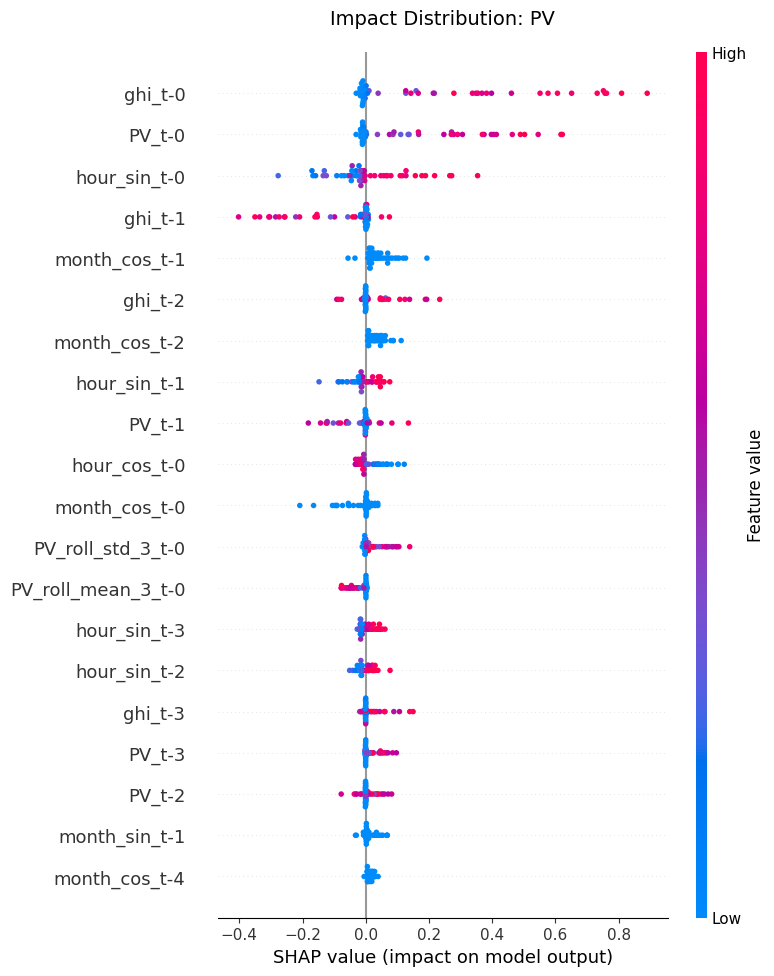

In [2]:

current_shap_raw = np.array(all_shap_dict[0])
s_flat, d_flat, names = get_flattened_data(current_shap_raw)
plt.figure(figsize=(10, 6))
shap.summary_plot(s_flat, d_flat, feature_names=names, show=False)
plt.title(f"Impact Distribution: PV", fontsize=14, pad=20)
plt.show()

### 2. Global Feature Importance
**What is this?** The mean absolute SHAP value for each feature.  
**What to focus on:** The length of the bar. It represents the "global" influence of a feature—how much it moves the prediction on average, regardless of direction.

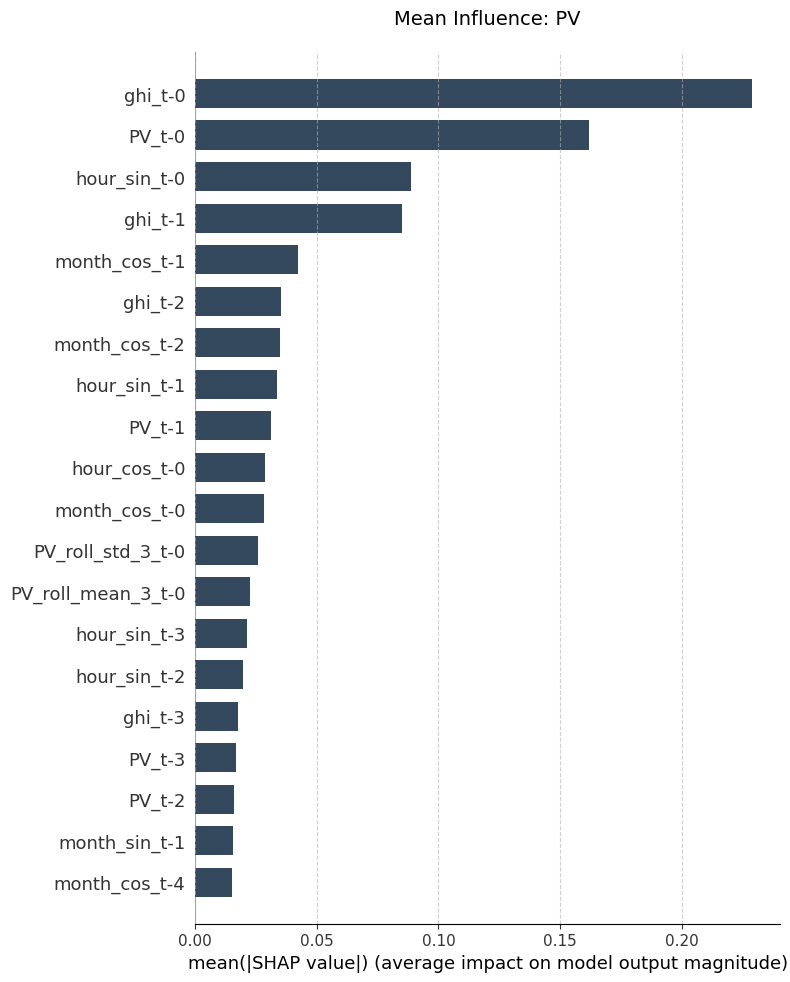

In [3]:

plt.figure(figsize=(10, 6))
shap.summary_plot(s_flat, d_flat, feature_names=names, plot_type='bar', show=False, color='#34495e')
plt.title(f"Mean Influence: PV", fontsize=14, pad=20)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

### 3. Temporal Relevance
**What is this?** A look at which time-steps in the `6` window are most influential.  
**What to focus on:** Does the model care more about the immediate past (`t-0`, `t-1`) or older history? A peak at `t-0` suggests a reactive model; a peak at `t-5` suggests a dependency on long-term trends.

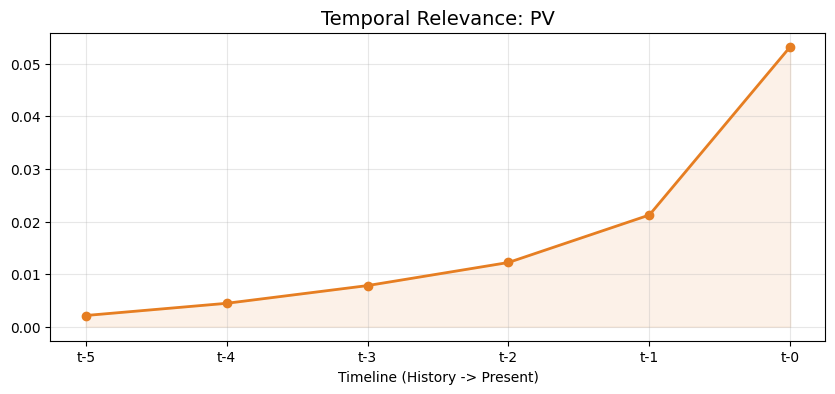

In [4]:

current_shap_raw = np.array(all_shap_dict[0])
importance_per_step = np.abs(current_shap_raw).mean(axis=(0, 2)).flatten()
time_labels = [f"t-{i}" for i in range(look_back-1, -1, -1)]
time_axis = list(range(len(time_labels)))

plt.figure(figsize=(10, 4))
plt.plot(time_axis, importance_per_step, marker='o', linewidth=2, color='#e67e22')
plt.xticks(time_axis, time_labels)
plt.title(f"Temporal Relevance: PV", fontsize=14)
plt.xlabel("Timeline (History -> Present)")
plt.fill_between(time_axis, importance_per_step, alpha=0.1, color='#e67e22')
plt.grid(True, alpha=0.3)
plt.show()

### 4. Focused View: Top 5 Drivers
**What is this?** A high-precision look at the five most critical variables for `PV`.  
**What to focus on:** The gap between the 1st and 5th feature. If the 1st is much larger, the model is heavily reliant on a single "smoking gun" variable.

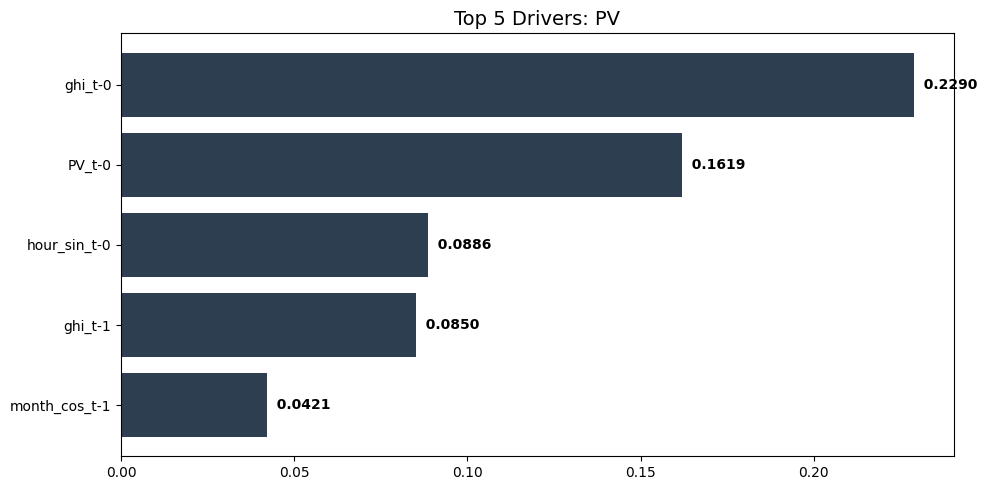

In [5]:

mean_shap = np.abs(s_flat).mean(axis=0)
sorted_idx = np.argsort(mean_shap)[-5:]
plt.figure(figsize=(10, 5))
plt.barh([names[i] for i in sorted_idx], mean_shap[sorted_idx], color='#2c3e50')
plt.title(f"Top 5 Drivers: PV", fontsize=14)
for i, v in enumerate(mean_shap[sorted_idx]):
    plt.text(v, i, f"  {v:.4f}", va='center', fontweight='bold')
plt.tight_layout()
plt.show()